# SWOT Analysis of Netflix Reviews

This notebook takes Netflix reviews from the Google Play Store and puts every opinion (segment) into one of the four SWOT categories (Strength, Weakness, Opportunity,Threat). After that it looks for the main topics inside each category with BERTopic and builds the final SWOT matrix with real quotes from the reviews.

The steps are: cleaning, splitting the reviews into short opinions, labelling a sample of them with Qwen2.5-7B, training a RoBERTa-large classifier on that sample, testing it on segments I annotated myself, topic modelling per category, and finally the SWOT matrix. The last section writes everything into a`data.json` file for the dashboard.

!The gold set is split by source review (`GroupShuffleSplit`), so segments coming from the same review never end up in train and test at the same time.

## 1. Setup

In [1]:
!pip install -q langdetect emoji rapidfuzz
!pip install -q sentence-transformers bertopic
!pip install -q bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 44.3 MB/s eta 0:00:00


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import re
import gc
import json
import hashlib

import numpy as np
import pandas as pd
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

SWOT_LABELS = ["Strength", "Weakness", "Opportunity", "Threat"]
UNCLASSIFIED = "Unclassified"      # segment that passes no threshold
FALLBACK_LABEL = "Weakness"        # only used in the demo, never on the corpus


def fingerprint(obj):
    return hashlib.md5(json.dumps(obj, sort_keys=True, default=str).encode()).hexdigest()[:12]

def cache_status(path, fp):
    """Returns 'valid', 'legacy' (exists, no meta), or 'missing'/'stale'."""
    if not os.path.exists(path):
        return "missing"
    meta = path + ".meta.json"
    if not os.path.exists(meta):
        print(f"WARNING: {os.path.basename(path)} has no fingerprint sidecar; "
              f"provenance cannot be verified (legacy cache).")
        return "legacy"
    saved = json.load(open(meta)).get("fp")
    if saved == fp:
        return "valid"
    print(f"Cache {os.path.basename(path)} is STALE (fp {saved} != {fp}); it will be rebuilt.")
    return "stale"

def write_cache_meta(path, fp):
    with open(path + ".meta.json", "w") as f:
        json.dump({"fp": fp}, f)


_persistent = "/kaggle/input/datasets/anastasiapolitidou/llm-labeled/silver_labeled.csv"
LLM_CACHE = _persistent if os.path.exists(_persistent) else "/kaggle/working/silver_labeled.csv"

print("CUDA available:", torch.cuda.is_available(), "| device count:", torch.cuda.device_count())


CUDA available: True | device count: 2


## 2. Loading the reviews (from 2020 on)

The dataset is pulled with `kagglehub` instead of a fixed path, so every run
picks up the newest version of the reviews.

In [3]:
import kagglehub, os
_ds = kagglehub.dataset_download("ashishkumarak/netflix-reviews-playstore-daily-updated")
REVIEWS_PATH = os.path.join(_ds, "netflix_reviews.csv")

df_raw = pd.read_csv(REVIEWS_PATH)
df_raw = df_raw[["content", "score", "at"]].rename(
    columns={"content": "text", "score": "rating", "at": "date"})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["rating"] = pd.to_numeric(df_raw["rating"], errors="coerce")
df_raw = df_raw[df_raw["date"] >= "2020-01-01"].reset_index(drop=True)

print("Reviews from 2020 onwards:", len(df_raw))
df_raw.head()

Reviews from 2020 onwards: 134231


,text,rating,date
0,love me some Netflix and the app is decent,5,2026-08-14 08:59:55
1,Good,5,2026-08-14 08:30:56
2,very fantastic app for movie's,5,2026-08-14 08:17:38
3,please i have suggested that your team play ba...,5,2026-08-14 08:05:50
4,"to gat my full ,FACTION",5,2026-08-14 08:04:50


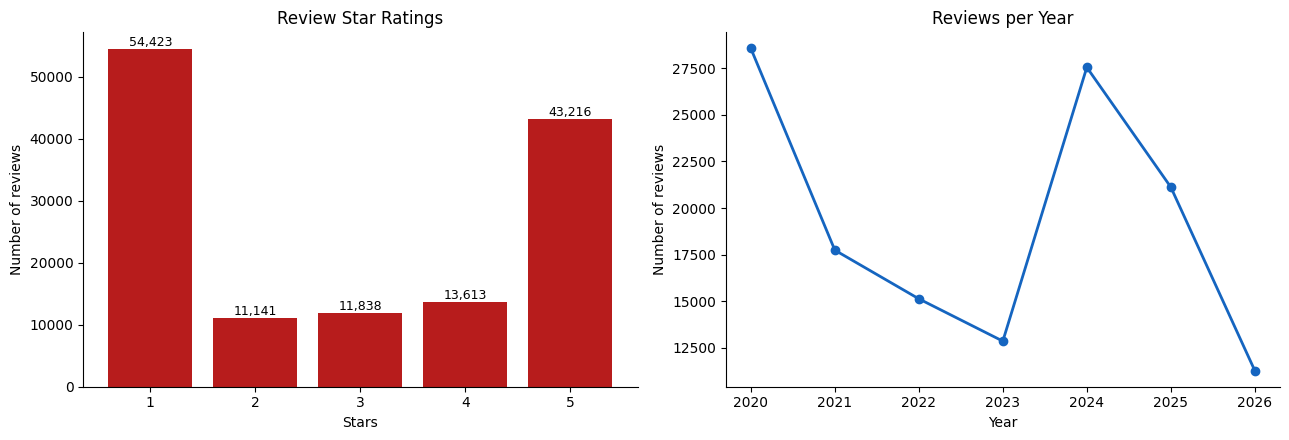

Total reviews: 134,231
Average rating: 2.85
Average review length: 25.2 words


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rc = df_raw["rating"].value_counts().sort_index()
axes[0].bar(rc.index.astype(int).astype(str), rc.values, color="#B71C1C")
for x, y in zip(range(len(rc)), rc.values):
    axes[0].text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Review Star Ratings"); axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Number of reviews"); axes[0].spines[["top","right"]].set_visible(False)

yr = df_raw.dropna(subset=["date"]).copy()
yr["year"] = yr["date"].dt.year
yc = yr["year"].value_counts().sort_index()
axes[1].plot(yc.index.astype(str), yc.values, marker="o", color="#1565C0", linewidth=2)
axes[1].set_title("Reviews per Year"); axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of reviews"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total reviews: {len(df_raw):,}")
print(f"Average rating: {df_raw['rating'].mean():.2f}")
print(f"Average review length: {df_raw['text'].astype(str).str.split().str.len().mean():.1f} words")

## 3. Cleaning the text

In [5]:
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import emoji
from rapidfuzz import process, fuzz

DetectorFactory.seed = SEED

LOW_INFO = {"good", "bad", "nice", "ok", "wow", "love it", "hate it",
            "very good", "very bad", "awesome", "terrible"}
SPAM_PATTERNS = [r"earn money", r"work from home", r"visit my channel",
                 r"subscribe to", r"check out my", r"promo code",
                 r"free followers", r"telegram", r"whatsapp"]


def detect_lang_safe(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"


def clean_text(text):
    text = str(text).strip().lower()
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\-\'\"]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def is_low_quality(text):
    if not isinstance(text, str):
        return True
    txt = text.strip()
    if len(txt) < 20 or len(txt.split()) < 4:
        return True
    if txt.lower() in LOW_INFO:
        return True
    if re.search(r"(.)\1{5,}", txt):                
        return True
    return False


def is_spam_like(text):
    txt = text.lower()
    return any(re.search(p, txt) for p in SPAM_PATTERNS)


def remove_near_duplicates(frame, text_col="text_clean", threshold=97):
    """Near-duplicate removal. Reviews are grouped by their first 20 chars
    and compared only inside each group, so the result does not depend on
    the order of the rows."""
    frame = frame.reset_index(drop=True)
    block = frame[text_col].str[:20]
    drop = set()
    for _, g in frame.groupby(block):
        if len(g) < 2:
            continue
        texts = g[text_col].tolist()
        sim = process.cdist(texts, texts, scorer=fuzz.ratio, workers=-1)
        gidx = g.index.to_numpy()
        for i in range(len(texts)):
            if gidx[i] in drop:
                continue
            dup = np.where(sim[i, i + 1:] >= threshold)[0] + i + 1
            drop.update(gidx[j] for j in dup)
    return frame.drop(index=list(drop)).reset_index(drop=True)

In [6]:
df = df_raw.dropna(subset=["text", "date"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() >= 15].copy()

df["lang"] = df["text"].apply(detect_lang_safe)
df = df[df["lang"] == "en"].copy()
print("After language filter:", len(df))

df["text_clean"] = df["text"].apply(clean_text)

before = len(df)
df = df[~df["text_clean"].apply(is_low_quality)]
df = df[~df["text_clean"].apply(is_spam_like)]
print("Removed low-quality / spam:", before - len(df))

before = len(df)
df = df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)
print("Removed exact duplicates:", before - len(df))

before = len(df)
df = remove_near_duplicates(df, threshold=97)
print("Removed near-duplicates:", before - len(df))

df = df.reset_index(drop=True)
df["review_id"] = df.index
print("Final cleaned reviews:", len(df))

After language filter: 115827
Removed low-quality / spam: 3901
Removed exact duplicates: 515
Removed near-duplicates: 98
Final cleaned reviews: 111313


## 4. Splitting reviews into short opinions

One review often has praise and a complaint in the same sentence, so sentences are also cut on words like but and however. The cut only happens when both sides can stand on their own: pieces that are too short, or that lost their subject in the split, are thrown away instead of becoming useless segments.

In [7]:
import spacy

nlp = spacy.load("en_core_web_sm",
                 disable=["tagger", "attribute_ruler", "lemmatizer", "ner"])
MIN_TOKENS = 7      
MIN_PART_TOKENS = 4   
CONTRAST = re.compile(r"\b(?:but|however|although|though)\b", re.I)
_LEAD_CONNECT = re.compile(
    r"^(?:and|or|so|also|then|plus|because|but|however|which|that)\b[\s,]*", re.I)
_SUBJECTLESS = re.compile(r"^(?:are|is|was|were|am|be|been|being|has|have|had)\b", re.I)
_DEPENDENT = re.compile(r"^(?:no matter|even if|even though|whether|as long as|in case)\b", re.I)

def _tidy(seg):
    seg = _LEAD_CONNECT.sub("", str(seg).strip(" ,.-"))
    return seg.strip(" ,.-")

def _valid(seg, min_tok):
    toks = seg.split()
    if len(toks) < min_tok:
        return False
    if _SUBJECTLESS.match(seg):
        return False
    if _DEPENDENT.match(seg) and len(toks) < 12:
        return False
    return True

def split_doc_into_segments(doc):
    segments = []
    for sent in doc.sents:
        s = _tidy(sent.text)
        if not s:
            continue
        parts = [_tidy(p) for p in CONTRAST.split(s)]
        parts = [p for p in parts if p]
        # only split on but/however if both sides stand on their own,
        # otherwise keep the sentence whole (the classifier is multi-label)
        if len(parts) >= 2 and all(_valid(p, MIN_PART_TOKENS) for p in parts):
            segments.extend(parts)
        elif _valid(s, MIN_TOKENS):
            segments.append(s)
    return segments


def split_review_into_segments(text):
    """Used by the demo in Section 21 for one single text."""
    return split_doc_into_segments(nlp(str(text)))

In [8]:
texts = df["text_clean"].astype(str).tolist()
segment_rows = []
for row, doc in zip(df.itertuples(index=False),
                    nlp.pipe(texts, batch_size=256)):
    for seg_id, seg in enumerate(split_doc_into_segments(doc)):
        segment_rows.append({
            "review_id": row.review_id,
            "segment_id": seg_id,
            "text_clean": seg,
            "rating": row.rating,
            "date": row.date,
        })

segments_df = pd.DataFrame(segment_rows)
print("Total segments:", len(segments_df))
segments_df.head()

Total segments: 198050


,review_id,segment_id,text_clean,rating,date
0,0,0,love me some netflix and the app is decent,5,2026-08-14 08:59:55
1,2,0,please i have suggested that your team play ba...,5,2026-08-14 08:05:50
2,4,0,"i always use this app and this is so fun,enter...",5,2026-08-14 07:58:58
3,5,0,never continues from the last episode i stopped,2,2026-08-14 07:40:07
4,6,0,"""netflix is my go-to for movies and shows",5,2026-08-14 07:25:45


## 5. Automatic labelling with the LLM

Qwen2.5-7B-Instruct labels a sample of the segments (the silver set). Every
prompt has the star rating plus a few examples. The result is cached, and the
cache is tied to a fingerprint of the model, the prompt, the sample size and the
seed, so if I change any of them the old file is not reused.

In [9]:
LLM_ID = "Qwen/Qwen2.5-7B-Instruct"
N_LLM = 6000
LLM_BATCH = 16

SWOT_DEFINITION = """Classify an app review segment into SWOT categories.
- Strength: the user PRAISES something (good content, quality, value, ease of use).
- Weakness: an EXISTING problem (bug, crash, error, poor support, bad/removed content).
- Opportunity: a REQUEST for something NEW (add a feature, content, or language).
- Threat: a BUSINESS RISK (price too high, cancellation, competitor comparison, loss of trust).
Rules: any bug/crash is always Weakness; "add/wish/please" a new thing is Opportunity;
churn/price/competitor is Threat."""

FEW_SHOT = """Rating: 5 | "great quality and streaming is fast" -> Strength
Rating: 1 | "app keeps crashing" -> Weakness
Rating: 4 | "should add tamil subtitles" -> Opportunity
Rating: 1 | "cancelling, too expensive" -> Threat
Rating: 2 | "content is poor and boring" -> Weakness
Rating: 1 | "amazon prime is cheaper" -> Threat
Rating: 3 | "clean interface but crashes a lot" -> Strength, Weakness"""

SILVER_FP = fingerprint({"llm": LLM_ID, "prompt": SWOT_DEFINITION + FEW_SHOT,
                         "n": N_LLM, "seed": SEED, "parser": "order-of-appearance-v2"})
SILVER_STATUS = cache_status(LLM_CACHE, SILVER_FP)
NEED_LLM = SILVER_STATUS in ("missing", "stale")

if NEED_LLM:
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    llm_tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
    llm_tokenizer.padding_side = "left"
    if llm_tokenizer.pad_token is None:
        llm_tokenizer.pad_token = llm_tokenizer.eos_token

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)

    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_ID, quantization_config=bnb_config, device_map="auto",
        max_memory={0: "13GiB", 1: "13GiB", "cpu": "24GiB"}, low_cpu_mem_usage=True)
    llm_model.eval()
    print("LLM loaded across:", set(llm_model.hf_device_map.values()))
else:
    print(f"Silver cache usable ({SILVER_STATUS}); skipping LLM load.")

Silver cache usable (legacy); skipping LLM load.


In [10]:
def build_prompt(text, rating):
    r = int(rating) if pd.notna(rating) else 3
    user_prompt = (
        SWOT_DEFINITION + "\n\n" + FEW_SHOT +
        "\n\nReturn ONLY the category names, nothing else.\n\n"
        f'Rating: {r} | "{text}" ->')
    messages = [
        {"role": "system", "content": "You classify app reviews into SWOT categories."},
        {"role": "user", "content": user_prompt},
    ]
    return llm_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)


def parse_labels(response):
    """Labels in the order they appear in the answer. If I returned them in
    SWOT_LABELS order instead, everything that takes the first label would be
    pushed towards Strength."""
    low = response.lower()
    found = [(low.find(lab.lower()), lab) for lab in SWOT_LABELS]
    return [lab for pos, lab in sorted(found) if pos != -1]


def llm_classify_batch(texts, ratings):
    prompts = [build_prompt(str(t), r) for t, r in zip(texts, ratings)]
    enc = llm_tokenizer(prompts, return_tensors="pt", padding=True,
                        truncation=True, max_length=512).to(llm_model.device)
    with torch.no_grad():
        out = llm_model.generate(
            **enc, max_new_tokens=20, do_sample=False,
            pad_token_id=llm_tokenizer.pad_token_id)
    gen = out[:, enc["input_ids"].shape[1]:]
    decoded = llm_tokenizer.batch_decode(gen, skip_special_tokens=True)
    return [parse_labels(d) for d in decoded]

In [11]:
if NEED_LLM:
    sanity_texts = ["good app with lots of movies", "it keeps freezing on my phone",
                    "please add greek subtitles", "too expensive i will cancel"]
    sanity_ratings = [5, 1, 4, 1]
    for t, labs in zip(sanity_texts, llm_classify_batch(sanity_texts, sanity_ratings)):
        print(f"{t!r:45} -> {labs}")
else:
    print("Silver cache in use; LLM sanity check skipped.")

Silver cache in use; LLM sanity check skipped.


## 6. The human gold set

These are the segments I annotated manually. The gold set is loaded before the silver sampling so that its segments can be removed from the LLM pool.

The split is done by source review with `GroupShuffleSplit`. Segments of the same review share a lot of vocabulary, so a normal random split would leak the review into both sides. A small calibration slice is taken out of the training part and is only used to pick ALPHA in Section 12.

In [12]:
HUMAN_PATH = "/kaggle/input/datasets/anastasiapolitidou/gold-segments/gold_segments.csv"

human_all = pd.read_csv(HUMAN_PATH)
human_all = human_all.rename(columns={"segment_text": "text_clean"})
human_all["manual_swot"] = human_all["manual_swot"].astype(str).str.strip()
human_all = human_all[human_all["manual_swot"].isin(SWOT_LABELS)].reset_index(drop=True)


def norm_text(s):
    return re.sub(r"\s+", " ", str(s).strip().lower())


human_all["parent_key"] = human_all["original_review"].apply(norm_text)

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.45, random_state=SEED)
train_idx, test_idx = next(gss.split(human_all, groups=human_all["parent_key"]))
human_train = human_all.iloc[train_idx].reset_index(drop=True)
human_test = human_all.iloc[test_idx].reset_index(drop=True)

gss_c = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
keep_idx, calib_idx = next(gss_c.split(human_train, groups=human_train["parent_key"]))
human_calib = human_train.iloc[calib_idx].reset_index(drop=True)
human_train = human_train.iloc[keep_idx].reset_index(drop=True)

TEST_PARENTS = set(human_test["parent_key"])

assert set(human_train["parent_key"]).isdisjoint(TEST_PARENTS)
assert set(human_calib["parent_key"]).isdisjoint(TEST_PARENTS)
assert set(human_calib["parent_key"]).isdisjoint(set(human_train["parent_key"]))
assert set(human_train["text_clean"]).isdisjoint(set(human_test["text_clean"]))

print(f"Human-labelled train: {len(human_train)} | calib: {len(human_calib)} | test: {len(human_test)}")
print(f"Source reviews -> train: {human_train['parent_key'].nunique()} | "
      f"calib: {human_calib['parent_key'].nunique()} | test: {len(TEST_PARENTS)}")
print("Test-set class distribution:")
print(human_test["manual_swot"].value_counts())

Human-labelled train: 140 | calib: 27 | test: 132
Source reviews -> train: 54 | calib: 14 | test: 56
Test-set class distribution:
manual_swot
Weakness       64
Strength       37
Threat         16
Opportunity    15
Name: count, dtype: int64


In [13]:
from tqdm.auto import tqdm

human_texts = set(human_all["text_clean"].astype(str))
human_parent_texts = set(human_test["original_review"].astype(str))

if not NEED_LLM:
    llm_df = pd.read_csv(LLM_CACHE)
    llm_df["labels"] = llm_df["labels"].apply(
        lambda s: [x for x in str(s).split("|") if x])
    print("Loaded cached silver labels:", len(llm_df))
else:
    llm_pool = segments_df[
        ~segments_df["text_clean"].astype(str).isin(human_texts)
        & ~segments_df["text_clean"].astype(str).isin(human_parent_texts)]
    llm_sample = llm_pool.sample(
        n=min(N_LLM, len(llm_pool)), random_state=SEED).reset_index(drop=True)
    s_texts = llm_sample["text_clean"].astype(str).tolist()
    s_rates = llm_sample["rating"].tolist()

    records = []
    for i in tqdm(range(0, len(s_texts), LLM_BATCH), desc="Annotation"):
        bt, br = s_texts[i:i + LLM_BATCH], s_rates[i:i + LLM_BATCH]
        for t, r, labels in zip(bt, br, llm_classify_batch(bt, br)):
            if labels:
                records.append({"text_clean": t, "rating": r, "labels": labels})

    llm_df = pd.DataFrame(records)
    cache_out = llm_df.copy()
    cache_out["labels"] = cache_out["labels"].apply(lambda L: "|".join(L))
    out_path = "/kaggle/working/silver_labeled.csv"
    cache_out.to_csv(out_path, index=False)
    write_cache_meta(out_path, SILVER_FP)
    print("Silver labels saved to:", out_path)

print("Silver segments:", len(llm_df))
for lab in SWOT_LABELS:
    print(f"  {lab:12}: {llm_df['labels'].apply(lambda L: lab in L).sum()}")

Loaded cached silver labels: 5993
Silver segments: 5993
  Strength    : 1808
  Weakness    : 3069
  Opportunity : 798
  Threat      : 692


In [14]:
if NEED_LLM:
    del llm_model
    gc.collect()
    torch.cuda.empty_cache()
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024 ** 3:.2f} GB")

### Leakage checks

The asserts below re-check the guarantees after loading, mostly to catch an old
cached silver file that was built under a different split.

In [15]:
assert set(human_test["text_clean"]).isdisjoint(set(llm_df["text_clean"])), \
    "Leakage: a gold test segment appears in the silver set."
assert TEST_PARENTS.isdisjoint(set(llm_df["text_clean"].apply(norm_text))), \
    "Leakage: a gold test parent review appears in the silver set."
print("Leakage checks passed (segment- and review-level).")
print(f"Human train: {len(human_train)} | test: {len(human_test)} | silver: {len(llm_df)}")

Leakage checks passed (segment- and review-level).
Human train: 140 | test: 132 | silver: 5993


## 7. Building the training set

The labels become a multi-hot vector of length 4. The silver data is split into a training and a validation part (validation is used for early stopping and for the thresholds). The gold test set is not touched here.

The human rows are repeated `HUMAN_WEIGHT` times, because the teacher gives fewer Weakness labels than I do. I compared x1, x3 and x6 on the silver validation split and x6 gave the best macro-F1. This also pulls the training prior towards the human prior, which is why ALPHA comes out 0 later on.

Every row also carries a `primary_label` (one single label): my own label for the gold rows, the first label in order of appearance for the silver ones. The baselines in Section 14 are trained on exactly this column and on exactly the same rows as RoBERTa.

In [16]:
from sklearn.model_selection import train_test_split

HUMAN_WEIGHT = 6


def to_multihot(label_list):
    return [1.0 if lab in label_list else 0.0 for lab in SWOT_LABELS]


llm_df = llm_df.copy()
llm_df["target"] = llm_df["labels"].apply(to_multihot)
llm_df["primary_label"] = llm_df["labels"].apply(lambda L: L[0])

llm_freq = {lab: int(llm_df["labels"].apply(lambda L: lab in L).sum())
            for lab in SWOT_LABELS}


def rarest_label(label_list):
    present = [lab for lab in label_list if lab in llm_freq]
    return min(present, key=lambda l: llm_freq[l]) if present else FALLBACK_LABEL


strat_key = llm_df["labels"].apply(rarest_label)
llm_train, llm_val = train_test_split(
    llm_df, test_size=0.15, random_state=SEED, stratify=strat_key)

human_train = human_train.copy()
human_train["target"] = human_train["manual_swot"].apply(lambda x: to_multihot([x]))
human_train["labels"] = human_train["manual_swot"].apply(lambda x: [x])
human_train["primary_label"] = human_train["manual_swot"]
human_train_weighted = pd.concat([human_train] * HUMAN_WEIGHT, ignore_index=True)

EXTRA_PATH = "/kaggle/input/datasets/anastasiapolitidou/review-swot-annotation-corrected/review_swot_annotation_corrected.csv"
human_extra = pd.read_csv(EXTRA_PATH)
human_extra["manual_swot"] = human_extra["manual_swot"].astype(str).str.strip()
human_extra = human_extra[human_extra["manual_swot"].isin(SWOT_LABELS)].copy()

human_extra["parent_key"] = human_extra["text_clean"].apply(norm_text)
blocked_parents = TEST_PARENTS | set(human_calib["parent_key"])
before_h = len(human_extra)
human_extra = human_extra[~human_extra["parent_key"].isin(blocked_parents)]
human_extra = human_extra[~human_extra["text_clean"].astype(str).isin(
    set(human_test["text_clean"].astype(str))
    | set(human_calib["text_clean"].astype(str)))]
print(f"Dropped {before_h - len(human_extra)} human reviews for review-level leakage.")

human_extra["labels"] = human_extra["manual_swot"].apply(lambda x: [x])
human_extra["target"] = human_extra["manual_swot"].apply(lambda x: to_multihot([x]))
human_extra["primary_label"] = human_extra["manual_swot"]

TRAIN_COLS = ["text_clean", "labels", "target", "primary_label"]
train_df = pd.concat(
    [llm_train[TRAIN_COLS], human_train_weighted[TRAIN_COLS], human_extra[TRAIN_COLS]],
    ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(f"Added {len(human_extra)} human-labelled reviews to training.")
print(f"Train rows: {len(train_df)} | silver val: {len(llm_val)}")
print("Training class counts:")
for lab in SWOT_LABELS:
    print(f"  {lab:12}: {train_df['labels'].apply(lambda L: lab in L).sum()}")

Dropped 70 human reviews for review-level leakage.
Added 230 human-labelled reviews to training.
Train rows: 6164 | silver val: 899
Training class counts:
  Strength    : 1803
  Weakness    : 3104
  Opportunity : 864
  Threat      : 708


## 8. Tokenization

Dynamic padding with `DataCollatorWithPadding` instead of padding everything to`max_length`. Same results, but clearly faster on short reviews.

In [17]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback, set_seed)
from datasets import Dataset

set_seed(SEED)

CLASSIFIER_ID = "roberta-large"
classifier_tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_ID)


def make_dataset(frame):
    ds = Dataset.from_dict({
        "text": frame["text_clean"].astype(str).tolist(),
        "labels": [list(map(float, t)) for t in frame["target"].tolist()],
    })
    ds = ds.map(lambda b: classifier_tokenizer(b["text"], truncation=True, max_length=96),
                batched=True)
    return ds.remove_columns(["text"])


train_ds = make_dataset(train_df)
val_ds = make_dataset(llm_val)
data_collator = DataCollatorWithPadding(tokenizer=classifier_tokenizer)
print("Datasets ready.")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6164 [00:00<?, ? examples/s]

Map:   0%|          | 0/899 [00:00<?, ? examples/s]

Datasets ready.


## 9. Training the classifier

RoBERTa-large with four sigmoid outputs and binary cross-entropy
(`problem_type="multi_label_classification"`), maximum 4 epochs with early
stopping on the silver validation macro-F1 and the best checkpoint kept. The 0.5
threshold inside `compute_metrics` is only used for picking the checkpoint, the
real thresholds come in Section 11.

In [18]:
from sklearn.metrics import f1_score, accuracy_score


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)
    return {
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "subset_acc": accuracy_score(labels, preds),
    }


def new_classifier():
    return AutoModelForSequenceClassification.from_pretrained(
        CLASSIFIER_ID, num_labels=4, problem_type="multi_label_classification",
        id2label={i: l for i, l in enumerate(SWOT_LABELS)},
        label2id={l: i for i, l in enumerate(SWOT_LABELS)})


train_args = TrainingArguments(
    output_dir="/kaggle/working/swot_model", num_train_epochs=4,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.1,
    lr_scheduler_type="cosine", eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    greater_is_better=True, report_to="none", seed=SEED,
    fp16=torch.cuda.is_available(), dataloader_pin_memory=False,
    save_total_limit=1, save_only_model=True)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [19]:
classifier_model = new_classifier()
trainer = Trainer(
    model=classifier_model, args=train_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer.train()
print("Training complete.")

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along 

Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Subset Acc
1,No log,0.481582,0.807507,0.762631,0.739711
2,No log,0.478611,0.801314,0.769650,0.730812
3,0.500788,0.463640,0.838470,0.800039,0.784205
4,0.500788,0.506883,0.839050,0.806226,0.788654


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training complete.


In [20]:
@torch.inference_mode()
def predict_proba(texts, batch_size=128):
    """Sigmoid probabilities from the fine-tuned classifier."""
    classifier_model.eval()
    device = classifier_model.device
    out = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i + batch_size]]
        enc = classifier_tokenizer(batch, truncation=True, padding=True,
                                   max_length=96, return_tensors="pt").to(device)
        with torch.autocast("cuda", enabled=device.type == "cuda"):
            logits = classifier_model(**enc).logits
        out.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.vstack(out)

## 10. Saving the model

In [21]:
classifier_model.save_pretrained("/kaggle/working/netflix-swot-model")
classifier_tokenizer.save_pretrained("/kaggle/working/netflix-swot-model")
print("Model saved to /kaggle/working/netflix-swot-model")

# upload to Hugging Face, only if the token is set
HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    classifier_model.push_to_hub("apolitidou/netflix-swot-classifier")
    classifier_tokenizer.push_to_hub("apolitidou/netflix-swot-classifier")
    print("Uploaded to Hugging Face Hub.")
else:
    print("HF_TOKEN not set; skipping upload.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/netflix-swot-model
HF_TOKEN not set; skipping upload.


## 11. Tuning the thresholds

One threshold per class, chosen on the silver validation split and then frozen.
The gold test set is never used here.

In [22]:
val_probs = predict_proba(llm_val["text_clean"].tolist())
val_true = np.array(llm_val["target"].tolist()).astype(int)

thresholds = {}
for c, cat in enumerate(SWOT_LABELS):
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.20, 0.71, 0.05):
        pred = (val_probs[:, c] >= t).astype(int)
        f1 = f1_score(val_true[:, c], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, round(float(t), 2)
    thresholds[cat] = best_t

thr_vec = np.array([thresholds[l] for l in SWOT_LABELS])
print("Tuned thresholds:", thresholds)

Tuned thresholds: {'Strength': 0.55, 'Weakness': 0.3, 'Opportunity': 0.45, 'Threat': 0.2}


## 12. Prior-shift correction 
The predicted probabilities can be reweighted towards the human class prior. The strength ALPHA is picked on the calibration slice from Section 6, which was taken out of the training side, so the test set stays untouched. With only 27 calibration segments this is noisy, so I keep it as a robustness check. The value that comes out is 0 (no correction), which fits with the oversampling in Section 7 that already moved the training prior towards the human one.

In [23]:
train_prior = np.array([train_df["labels"].apply(lambda L: lab in L).mean()
                        for lab in SWOT_LABELS])
human_prior = np.array([(human_train["manual_swot"] == lab).mean() for lab in SWOT_LABELS])
prior_ratio = human_prior / np.clip(train_prior, 1e-6, None)

calib_probs = predict_proba(human_calib["text_clean"].tolist())
calib_true = human_calib["manual_swot"].tolist()
calib_yt = np.array([to_multihot([x]) for x in calib_true]).astype(int)


def _balanced_objective(p, true_labels, yt):
    idx = p.argmax(axis=1)
    pred = [SWOT_LABELS[i] for i in idx]
    yp = np.zeros_like(yt); yp[np.arange(len(idx)), idx] = 1
    a = accuracy_score(true_labels, pred)
    m = f1_score(yt, yp, average="macro", zero_division=0)
    return 0.5 * a + 0.5 * m


best_alpha, best_obj = 0.0, -1.0
for a in np.arange(0.0, 1.01, 0.1):
    obj = _balanced_objective(calib_probs * (prior_ratio ** a), calib_true, calib_yt)
    if obj > best_obj:
        best_obj, best_alpha = obj, round(float(a), 1)

ALPHA = best_alpha
print(f"Selected ALPHA (on the human calibration slice): {ALPHA}")
print("Prior ratio:", {l: round(float(r), 2) for l, r in zip(SWOT_LABELS, prior_ratio)})

Selected ALPHA (on the human calibration slice): 0.0
Prior ratio: {'Strength': 0.88, 'Weakness': 0.95, 'Opportunity': 1.22, 'Threat': 0.81}


## 13. Testing on the gold test set

Two decision rules are reported:

1. **Argmax**: one label per segment. This is the one that can be compared with
   my single-label annotation and with the baselines.
2. **Production rule**: per-class thresholds and `Unclassified` when nothing
   passes. This is exactly the rule that labels the corpus in Section 17, so it
   makes sense to check it on human data too.

In [24]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

probs_test = predict_proba(human_test["text_clean"].tolist())
probs_test = probs_test * (prior_ratio ** ALPHA)      
true_label = human_test["manual_swot"].tolist()
y_true = np.array([to_multihot([x]) for x in true_label]).astype(int)

pred_idx = probs_test.argmax(axis=1)
pred_label = [SWOT_LABELS[i] for i in pred_idx]
y_pred = np.zeros_like(y_true)
y_pred[np.arange(len(pred_idx)), pred_idx] = 1

acc = accuracy_score(true_label, pred_label)
micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("=" * 64)
print("TEST RESULTS — argmax rule (one label per segment)")
print("=" * 64)
print(f"Overall accuracy : {acc:.4f}  ({acc * 100:.1f}%)")
print(f"Micro F1-score   : {micro_f1:.4f}")
print(f"Macro F1-score   : {macro_f1:.4f}")
print("-" * 64)
print(classification_report(true_label, pred_label,
                            labels=SWOT_LABELS, zero_division=0))

TEST RESULTS — argmax rule (one label per segment)
Overall accuracy : 0.8409  (84.1%)
Micro F1-score   : 0.8409
Macro F1-score   : 0.7982
----------------------------------------------------------------
              precision    recall  f1-score   support

    Strength       0.97      0.89      0.93        37
    Weakness       0.87      0.86      0.87        64
 Opportunity       0.71      0.80      0.75        15
      Threat       0.61      0.69      0.65        16

    accuracy                           0.84       132
   macro avg       0.79      0.81      0.80       132
weighted avg       0.85      0.84      0.84       132



In [25]:
prod_sets = []
for p in probs_test:
    accepted = [SWOT_LABELS[i] for i in range(4) if p[i] >= thr_vec[i]]
    prod_sets.append(accepted)

n_unc = sum(1 for s in prod_sets if not s)
gold_in_set = np.mean([t in s for t, s in zip(true_label, prod_sets)])
avg_card = np.mean([len(s) for s in prod_sets if s]) if len(prod_sets) > n_unc else 0.0
top1_prod = [max(s, key=lambda l: probs_test[k, SWOT_LABELS.index(l)]) if s else UNCLASSIFIED
             for k, s in enumerate(prod_sets)]
acc_prod_top1 = np.mean([p == t for p, t in zip(top1_prod, true_label)])

print("PRODUCTION RULE on the gold test set")
print(f"  Gold label contained in predicted set : {gold_in_set:.3f}")
print(f"  Avg labels per classified segment     : {avg_card:.2f}")
print(f"  Unclassified segments                 : {n_unc}/{len(prod_sets)}")
print(f"  Top-1 accuracy (Unclassified = wrong) : {acc_prod_top1:.3f}")

PRODUCTION RULE on the gold test set
  Gold label contained in predicted set : 0.871
  Avg labels per classified segment     : 1.08
  Unclassified segments                 : 1/132
  Top-1 accuracy (Unclassified = wrong) : 0.841


In [26]:
prec, rec, f1c, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(4), zero_division=0)

print("Per-class metrics on the gold test set (argmax rule)")
print(f"{'Class':12} {'Precision':>10} {'Recall':>10} {'F1':>10} "
      f"{'Acc(incl.TN)':>13} {'Support':>9}")
for i, lab in enumerate(SWOT_LABELS):
    cls_acc = (y_true[:, i] == y_pred[:, i]).mean()
    print(f"{lab:12} {prec[i]:>10.3f} {rec[i]:>10.3f} {f1c[i]:>10.3f} "
          f"{cls_acc * 100:>12.1f}% {int(support[i]):>9}")

Per-class metrics on the gold test set (argmax rule)
Class         Precision     Recall         F1  Acc(incl.TN)   Support
Strength          0.971      0.892      0.930         96.2%        37
Weakness          0.873      0.859      0.866         87.1%        64
Opportunity       0.706      0.800      0.750         93.9%        15
Threat            0.611      0.688      0.647         90.9%        16


## 14. Comparison with simple baselines

Both baselines are trained on exactly the same rows as RoBERTa (`train_df`,
column `primary_label`). If they were trained on the full silver set the
comparison would mix up the architecture with the training data.

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

majority = DummyClassifier(strategy="most_frequent").fit(
    train_df["text_clean"], train_df["primary_label"])
acc_majority = accuracy_score(true_label, majority.predict(human_test["text_clean"]))

tfidf_lr = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000, class_weight="balanced"))
tfidf_lr.fit(train_df["text_clean"], train_df["primary_label"])
acc_tfidf = accuracy_score(true_label, tfidf_lr.predict(human_test["text_clean"]))

print(f"Baseline comparison ({len(human_test)} gold segments, identical training rows)")
print(f"  Majority class        : {acc_majority:.3f}")
print(f"  TF-IDF + LogReg       : {acc_tfidf:.3f}")
print(f"  Fine-tuned RoBERTa    : {acc:.3f}")


Baseline comparison (132 gold segments, identical training rows)
  Majority class        : 0.485
  TF-IDF + LogReg       : 0.720
  Fine-tuned RoBERTa    : 0.841


In [28]:
# Difference with the TF-IDF
from statsmodels.stats.contingency_tables import mcnemar

model_pred = list(pred_label)
tfidf_pred = list(tfidf_lr.predict(human_test["text_clean"]))
truth = list(true_label)

model_ok = np.array([p == t for p, t in zip(model_pred, truth)])
tfidf_ok = np.array([p == t for p, t in zip(tfidf_pred, truth)])

b = int(np.sum(model_ok & ~tfidf_ok))
c = int(np.sum(~model_ok & tfidf_ok))
table = [[int(np.sum(model_ok & tfidf_ok)), b],
         [c, int(np.sum(~model_ok & ~tfidf_ok))]]
res = mcnemar(table, exact=False, correction=True)
print("McNemar test (model vs TF-IDF baseline)")
print(f"  model-only correct: {b} | baseline-only correct: {c}")
print(f"  statistic = {res.statistic:.3f} | p-value = {res.pvalue:.4f}")
print(f"  {'Significant (p<0.05)' if res.pvalue < 0.05 else 'Not significant (p>=0.05)'}")

rng = np.random.RandomState(SEED)
n = len(truth); diffs = []
for _ in range(5000):
    idx = rng.choice(n, n, replace=True)
    diffs.append(model_ok[idx].mean() - tfidf_ok[idx].mean())
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"\nAccuracy difference (model - baseline): {np.mean(diffs):.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
print(f"  {'Significant' if lo > 0 else 'Not significant'} (CI {'excludes' if lo > 0 else 'includes'} 0)")

McNemar test (model vs TF-IDF baseline)
  model-only correct: 22 | baseline-only correct: 6
  statistic = 8.036 | p-value = 0.0046
  Significant (p<0.05)

Accuracy difference (model - baseline): 0.121  95% CI [0.045, 0.197]
  Significant (CI excludes 0)


## 15. Bootstrap confidence intervals, confusion matrix and error analysis

In [29]:
rng = np.random.RandomState(SEED)
n = len(true_label)
true_arr = np.array(true_label)
pred_arr = np.array(pred_label)
yt = np.array([to_multihot([x]) for x in true_label]).astype(int)
yp = np.array([to_multihot([x]) for x in pred_label]).astype(int)

B = 2000
boot = {"accuracy": [], "micro_f1": [], "macro_f1": []}
boot_cls = {lab: [] for lab in SWOT_LABELS}
for _ in range(B):
    idx = rng.choice(n, n, replace=True)
    boot["accuracy"].append(accuracy_score(true_arr[idx], pred_arr[idx]))
    boot["micro_f1"].append(f1_score(yt[idx], yp[idx], average="micro", zero_division=0))
    boot["macro_f1"].append(f1_score(yt[idx], yp[idx], average="macro", zero_division=0))
    for ci_, lab in enumerate(SWOT_LABELS):
        boot_cls[lab].append(f1_score(yt[idx, ci_], yp[idx, ci_], zero_division=0))


def ci(vals):
    return np.percentile(vals, [2.5, 97.5])


print("Metric         point   95% CI")
for k in ["accuracy", "micro_f1", "macro_f1"]:
    lo, hi = ci(boot[k])
    print(f"{k:12}  {np.mean(boot[k]):.3f}  [{lo:.3f}, {hi:.3f}]")
print("\nPer-class F1 (95% CI), the intervals are wide for the small classes:")
for lab in SWOT_LABELS:
    lo, hi = ci(boot_cls[lab])
    print(f"  {lab:12} {np.mean(boot_cls[lab]):.3f}  [{lo:.3f}, {hi:.3f}]")

Metric         point   95% CI
accuracy      0.841  [0.773, 0.902]
micro_f1      0.841  [0.773, 0.902]
macro_f1      0.794  [0.710, 0.871]

Per-class F1 (95% CI), the intervals are wide for the small classes:
  Strength     0.929  [0.862, 0.985]
  Weakness     0.865  [0.793, 0.923]
  Opportunity  0.743  [0.545, 0.897]
  Threat       0.639  [0.424, 0.818]


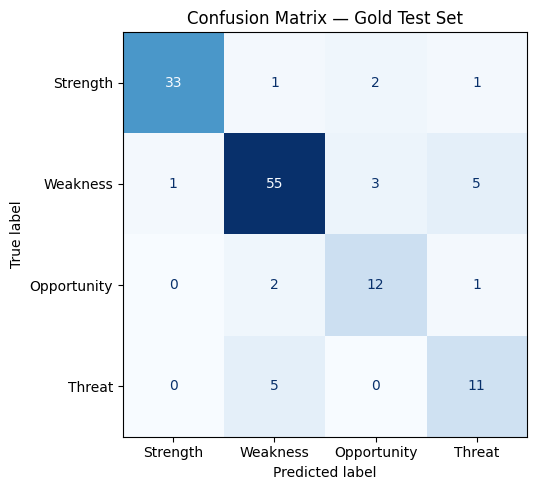

Row-normalised (recall per true class):
true/pred        Strength     Weakness  Opportunity       Threat
Strength             0.89         0.03         0.05         0.03
Weakness             0.02         0.86         0.05         0.08
Opportunity          0.00         0.13         0.80         0.07
Threat               0.00         0.31         0.00         0.69


In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_label, pred_label, labels=SWOT_LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=SWOT_LABELS).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix — Gold Test Set")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Row-normalised (recall per true class):")
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
print(f"{'true/pred':12}" + "".join(f"{l:>13}" for l in SWOT_LABELS))
for i, lab in enumerate(SWOT_LABELS):
    print(f"{lab:12}" + "".join(f"{cm_norm[i, j]:>13.2f}" for j in range(len(SWOT_LABELS))))

In [31]:
# which segments got it wrong, and how sure the model was
err_rows = []
for k in range(len(human_test)):
    if true_label[k] != pred_label[k]:
        err_rows.append({
            "text": human_test["text_clean"].iloc[k][:90],
            "true": true_label[k],
            "predicted": pred_label[k],
            "p_true": round(float(probs_test[k, SWOT_LABELS.index(true_label[k])]), 2),
            "p_pred": round(float(probs_test[k, SWOT_LABELS.index(pred_label[k])]), 2),
        })

errors_df = pd.DataFrame(err_rows)
print(f"Total misclassified: {len(errors_df)} / {len(human_test)}")
print("\nMost common confusions (true -> predicted):")
print((errors_df["true"] + " -> " + errors_df["predicted"]).value_counts().head(8))
print("\nSample of misclassified segments (low p_true = likely ambiguous or label noise):")
errors_df.sort_values("p_true").head(15)

Total misclassified: 21 / 132

Most common confusions (true -> predicted):
Weakness -> Threat         5
Threat -> Weakness         5
Weakness -> Opportunity    3
Strength -> Opportunity    2
Opportunity -> Weakness    2
Weakness -> Strength       1
Strength -> Weakness       1
Opportunity -> Threat      1
Name: count, dtype: int64

Sample of misclassified segments (low p_true = likely ambiguous or label noise):


,text,true,predicted,p_true,p_pred
3,last month on this app,Threat,Weakness,0.00,0.94
11,i just wish it could accommodate other phone b...,Strength,Opportunity,0.01,0.99
5,"this app sucks, bye netflix",Threat,Weakness,0.02,0.99
2,"not enough options for tv series or movies, at...",Weakness,Opportunity,0.02,0.99
10,because all movie old for users,Opportunity,Weakness,0.02,0.99
17,from last 15 days i want to sign in with netflix,Weakness,Opportunity,0.02,0.98
6,"i don't know why ratings are only 3.9 , i am d...",Strength,Weakness,0.03,0.96
4,i can cast other apps,Weakness,Threat,0.03,0.68
9,use to be better,Threat,Weakness,0.04,0.95
18,i can even get premium games too,Strength,Threat,0.05,0.96


## 16. Teacher vs student

The Qwen teacher runs few-shot on the same gold test segments, to see how far
the distilled student is from it.

In [32]:
LLM_PRED_CACHE = "/kaggle/working/llm_test_pred.csv"
LLMTEST_FP = fingerprint({"llm": LLM_ID, "prompt": SWOT_DEFINITION + FEW_SHOT,
                          "parser": "order-of-appearance-v2",
                          "test": sorted(human_test["text_clean"].astype(str))})

llm_test_pred = None
if cache_status(LLM_PRED_CACHE, LLMTEST_FP) == "valid":
    _tc = pd.read_csv(LLM_PRED_CACHE).drop_duplicates("text_clean").set_index("text_clean")
    if human_test["text_clean"].isin(_tc.index).all():
        llm_test_pred = _tc.loc[human_test["text_clean"], "pred"].tolist()
        print("Loaded cached teacher predictions.")

if llm_test_pred is None:
    # move the classifier to CPU, otherwise Qwen does not fit on the GPU
    if "trainer" in dir():
        del trainer
    classifier_model.to("cpu")
    gc.collect(); torch.cuda.empty_cache()

    if "llm_model" not in dir():
        from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
        llm_tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
        llm_tokenizer.padding_side = "left"
        if llm_tokenizer.pad_token is None:
            llm_tokenizer.pad_token = llm_tokenizer.eos_token
        _bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                                  bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True)
        llm_model = AutoModelForCausalLM.from_pretrained(
            LLM_ID, quantization_config=_bnb, device_map="auto",
            max_memory={0: "13GiB", 1: "13GiB", "cpu": "24GiB"}, low_cpu_mem_usage=True)
        llm_model.eval()
        print("Teacher reloaded for gold-set evaluation.")

    from tqdm.auto import tqdm
    g_texts = human_test["text_clean"].astype(str).tolist()
    g_rates = (human_test["rating"].tolist() if "rating" in human_test.columns
               else [3] * len(g_texts))
    llm_test_pred = []
    for i in tqdm(range(0, len(g_texts), 16), desc="Teacher on gold set"):
        for labs in llm_classify_batch(g_texts[i:i + 16], g_rates[i:i + 16]):
            llm_test_pred.append(labs[0] if labs else FALLBACK_LABEL)
    pd.DataFrame({"text_clean": human_test["text_clean"], "pred": llm_test_pred}).to_csv(
        LLM_PRED_CACHE, index=False)
    write_cache_meta(LLM_PRED_CACHE, LLMTEST_FP)

    del llm_model
    gc.collect(); torch.cuda.empty_cache()
    if torch.cuda.is_available():
        classifier_model.to("cuda")

t_true = human_test["manual_swot"].tolist()
t_acc = accuracy_score(t_true, llm_test_pred)
t_yt = np.array([[1 if t == l else 0 for l in SWOT_LABELS] for t in t_true])
t_yp = np.array([[1 if p == l else 0 for l in SWOT_LABELS] for p in llm_test_pred])
print("=" * 60)
print("TEACHER (Qwen2.5-7B few-shot) vs STUDENT (fine-tuned RoBERTa)")
print("=" * 60)
print(f"{'':22}{'Accuracy':>12}{'Macro-F1':>12}")
print(f"{'Teacher (Qwen)':22}{t_acc:>12.3f}"
      f"{f1_score(t_yt, t_yp, average='macro', zero_division=0):>12.3f}")
print(f"{'Student (RoBERTa)':22}{acc:>12.3f}{macro_f1:>12.3f}")
print("-" * 60)
print("Teacher per-class report:")
print(classification_report(t_true, llm_test_pred, labels=SWOT_LABELS, zero_division=0))

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Teacher reloaded for gold-set evaluation.


Teacher on gold set:   0%|          | 0/9 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEACHER (Qwen2.5-7B few-shot) vs STUDENT (fine-tuned RoBERTa)
                          Accuracy    Macro-F1
Teacher (Qwen)               0.780       0.729
Student (RoBERTa)            0.841       0.798
------------------------------------------------------------
Teacher per-class report:
              precision    recall  f1-score   support

    Strength       0.84      0.97      0.90        37
    Weakness       0.85      0.73      0.79        64
 Opportunity       0.58      0.73      0.65        15
      Threat       0.60      0.56      0.58        16

    accuracy                           0.78       132
   macro avg       0.72      0.75      0.73       132
weighted avg       0.79      0.78      0.78       132



## 17. Labelling the whole corpus

Segments that pass no threshold stay `Unclassified` instead of being pushed into
Weakness, and the coverage is printed. The saved corpus cache is skipped on
purpose, so that a new run always re-classifies the newest reviews.

In [33]:
CORPUS_FP = fingerprint({"clf": CLASSIFIER_ID, "thr": thresholds, "alpha": ALPHA,
                         "silver": SILVER_FP, "rule": "unclassified-v2"})
_persistent_corpus = "/kaggle/input/datasets/anastasiapolitidou/corpus-classified/corpus_classified.csv"

USE_CORPUS_CACHE = False
if not USE_CORPUS_CACHE:
    _persistent_corpus = "___disabled___"
CORPUS_CACHE = (_persistent_corpus if os.path.exists(_persistent_corpus)
                else "/kaggle/working/corpus_classified.csv")

if cache_status(CORPUS_CACHE, CORPUS_FP) == "valid":
    df_swot = pd.read_csv(CORPUS_CACHE)
    df_swot["date"] = pd.to_datetime(df_swot["date"], errors="coerce")
    print("Loaded cached corpus classification:", len(df_swot))
else:
    segments_reset = segments_df.reset_index(drop=True)
    p_all = predict_proba(segments_reset["text_clean"].astype(str).tolist(), batch_size=256)
    p_all = p_all * (prior_ratio ** ALPHA)
    acc_mask = p_all >= thr_vec                        

    frames = []
    for c, lab in enumerate(SWOT_LABELS):
        idx = np.where(acc_mask[:, c])[0]
        f = segments_reset.iloc[idx].copy()
        f["swot_category"] = lab
        f["swot_confidence"] = p_all[idx, c]
        frames.append(f)
    unc_idx = np.where(~acc_mask.any(axis=1))[0]
    unc = segments_reset.iloc[unc_idx].copy()
    unc["swot_category"] = UNCLASSIFIED
    unc["swot_confidence"] = p_all[unc_idx].max(axis=1)
    frames.append(unc)

    df_swot = pd.concat(frames, ignore_index=True)
    out_path = "/kaggle/working/corpus_classified.csv"
    df_swot.to_csv(out_path, index=False)
    write_cache_meta(out_path, CORPUS_FP)

CLASSIFIED = df_swot[df_swot["swot_category"] != UNCLASSIFIED].copy()
coverage = (df_swot["swot_category"] != UNCLASSIFIED).mean()
print(f"Total segment-label pairs : {len(df_swot)}")
print(f"Classifier coverage       : {coverage:.1%} "
      f"({(df_swot['swot_category'] == UNCLASSIFIED).sum()} unclassified rows)")
print(df_swot["swot_category"].value_counts())

Total segment-label pairs : 221283
Classifier coverage       : 99.7% (725 unclassified rows)
swot_category
Weakness        109540
Strength         50365
Threat           30330
Opportunity      30323
Unclassified       725
Name: count, dtype: int64


## 18. Embedding each SWOT group

Every classified segment is turned into a vector with `all-mpnet-base-v2`.
Themes are induced and assigned in this same space in the next section.

In [34]:
from sentence_transformers import SentenceTransformer

# Only the embeddings are needed: themes are induced and assigned in this same
# vector space (section 8). Clustering is not used, so nothing here beyond the
# encoder is computed.
if torch.cuda.is_available():
    classifier_model.to("cpu")
gc.collect(); torch.cuda.empty_cache()

embedding_model = SentenceTransformer("all-mpnet-base-v2")


def embed_category(category):
    cat_df = CLASSIFIED[(CLASSIFIED["swot_category"] == category)
                        & CLASSIFIED["text_clean"].notna()].reset_index(drop=True)
    if len(cat_df) < 100:
        print(f"{category}: only {len(cat_df)} segments, skipped")
        return {"df": cat_df, "emb": None}
    emb = embedding_model.encode(cat_df["text_clean"].astype(str).tolist(),
                                 batch_size=256, show_progress_bar=True,
                                 normalize_embeddings=True).astype(np.float32)
    print(f"{category}: {len(cat_df):,} segments embedded")
    return {"df": cat_df, "emb": emb}


topic_data = {c: embed_category(c) for c in SWOT_LABELS}


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

Weakness: 109,540 segments embedded


Batches:   0%|          | 0/119 [00:00<?, ?it/s]

Opportunity: 30,323 segments embedded


Batches:   0%|          | 0/119 [00:00<?, ?it/s]

Threat: 30,330 segments embedded


## 19. Themes

Clustering short review sentences produced hundreds of fragments that no label
could describe, so this stage works the other way round:

1. A random sample of real reviews from the quadrant is read by the model,
   which lists the recurring themes it sees. Nothing is predefined.
2. Near-identical proposals are merged in the embedding space.
3. **Every** segment of the corpus is then assigned to its closest theme by
   cosine similarity. This part is pure measurement.
4. A theme survives only if enough distinct reviews attach to it, and its
   description is accepted only if it stays close to the theme's centre.

The model proposes, the data decides: the counts, the ranking, the ratings and
the trends all come from the assignment, never from the model.

In [35]:
SPLIT_DATE = pd.to_datetime(CLASSIFIED["date"], errors="coerce").median()
CAT_RECENT_SHARE = {
    c: (pd.to_datetime(CLASSIFIED.loc[CLASSIFIED["swot_category"] == c, "date"],
                       errors="coerce") >= SPLIT_DATE).mean()
    for c in SWOT_LABELS}

def topic_trend(df_t, cat_share):
    d = pd.to_datetime(df_t["date"], errors="coerce").dropna()
    if len(d) < 10:
        return "STABLE"
    recent = (d >= SPLIT_DATE).mean()
    if recent >= cat_share + 0.10:
        return "RISING"
    if recent <= cat_share - 0.10:
        return "FALLING"
    return "STABLE"

def mmr_quotes(texts, emb, k=6, diversity=0.4, pool=50):
    centroid = emb.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-9)
    sims = emb @ centroid
    cand = list(np.argsort(-sims)[:pool])
    selected = [cand[0]]
    while len(selected) < min(k * 2, len(cand)):
        rest = [c for c in cand if c not in selected]
        if not rest:
            break
        scores = [((1 - diversity) * sims[c]
                   - diversity * max(float(emb[c] @ emb[s]) for s in selected), c)
                  for c in rest]
        selected.append(max(scores)[1])
    picked = [texts[i].strip() for i in selected if len(texts[i].split()) >= 5][:k]
    return picked or [texts[cand[0]]]



from transformers import AutoModelForCausalLM, BitsAndBytesConfig

MIN_THEME_SHARE    = 0.005    # a theme must be raised by 0.5% of the quadrant
ASSIGN_MIN_SIM     = 0.30     # below this a segment belongs to no theme
MERGE_SIM          = 0.70     # two proposals this close are the same theme
SAMPLE_PER_CAT     = 560
BATCH              = 80

THEME_ID = "Qwen/Qwen2.5-7B-Instruct"
theme_tokenizer = AutoTokenizer.from_pretrained(THEME_ID)
if theme_tokenizer.pad_token is None:
    theme_tokenizer.pad_token = theme_tokenizer.eos_token
theme_model = AutoModelForCausalLM.from_pretrained(
    THEME_ID,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True),
    device_map="auto", max_memory={0: "14GiB", "cpu": "24GiB"},
    low_cpu_mem_usage=True)
theme_model.eval()

CATEGORY_BRIEF = {
    "Strength": "what users praise about the service",
    "Weakness": "what does not work or frustrates users",
    "Opportunity": "what users ask to be added or improved",
    "Threat": "what pushes users to cancel or leave for a competitor",
}


def propose_themes(reviews, category):
    """Asks the model which themes it sees in this sample. Free-form: no list
    of allowed themes is given, so the taxonomy comes from the reviews."""
    numbered = "\n".join(f"- {r}" for r in reviews)
    user_msg = f"""Below are real Netflix app reviews, all about {CATEGORY_BRIEF[category]}.

{numbered}

List the recurring themes you can see. For each theme write one line:
Theme Name | keyword, keyword, keyword

Rules:
- The theme name is 2 to 5 words, concrete, the way a business report would
  phrase it (for example: Frequent Price Increases, Subtitle Language Gaps).
- Only themes that several of these reviews share. Ignore one-off remarks.
- At most 10 themes. Return only the lines, nothing else."""
    messages = [{"role": "system",
                 "content": "You group customer feedback into recurring themes."},
                {"role": "user", "content": user_msg}]
    prompt = theme_tokenizer.apply_chat_template(messages, tokenize=False,
                                                 add_generation_prompt=True)
    enc = theme_tokenizer(prompt, return_tensors="pt", truncation=True,
                          max_length=3500).to(theme_model.device)
    with torch.no_grad():
        out = theme_model.generate(**enc, max_new_tokens=220, do_sample=False,
                                   pad_token_id=theme_tokenizer.pad_token_id)
    text = theme_tokenizer.decode(out[0][enc["input_ids"].shape[1]:],
                                  skip_special_tokens=True)
    themes = []
    for line in text.split("\n"):
        line = line.strip().lstrip("-*0123456789. ").strip()
        if "|" not in line:
            continue
        name, kw = line.split("|", 1)
        name = re.sub(r"[^A-Za-z0-9 &'-]", " ", name).strip()
        name = re.sub(r"\s+", " ", name)
        # the model sometimes echoes the name several times in one line
        _w = name.split()
        for _n in range(1, len(_w) // 2 + 1):
            if len(_w) % _n == 0 and all(_w[j] == _w[j % _n] for j in range(len(_w))):
                name = " ".join(_w[:_n])
                break
        kw = re.sub(r"[^A-Za-z0-9, '-]", " ", kw).strip()
        if 2 <= len(name.split()) <= 6 and kw:
            themes.append((name, kw))
    return themes


def merge_themes(themes):
    """Drops proposals that say the same thing as one already kept."""
    if not themes:
        return []
    texts = [f"{n}: {k}" for n, k in themes]
    emb = embedding_model.encode(texts, normalize_embeddings=True,
                                 show_progress_bar=False)
    kept, kept_emb = [], []
    for i, t in enumerate(themes):
        if kept_emb and max(float(emb[i] @ e) for e in kept_emb) >= MERGE_SIM:
            continue
        kept.append(t)
        kept_emb.append(emb[i])
    return kept


NEIGHBOUR_SIM = 0.55      # two segments this close say the same thing
DIVERSITY_SIM = 0.55      # one candidate per distinct opinion, so the
                          # sample mirrors how much each theme is discussed
REFERENCE_N   = 12000     # segments the density is measured against
CANDIDATE_N   = 30000


def popular_sample(cat_df, emb, k=None):
    """The segments the largest number of other reviews echo, one per distinct
    opinion. Deterministic: no random draw decides which themes are proposed."""
    k = k or SAMPLE_PER_CAT
    long_enough = cat_df["text_clean"].astype(str).str.split().str.len() >= 6
    idx = np.where(long_enough.to_numpy())[0]
    if len(idx) <= k:
        return cat_df["text_clean"].astype(str).iloc[idx].tolist()

    # evenly spaced, so the reference set covers the whole quadrant
    ref = idx[np.linspace(0, len(idx) - 1, min(REFERENCE_N, len(idx))).astype(int)]
    cand = idx[np.linspace(0, len(idx) - 1, min(CANDIDATE_N, len(idx))).astype(int)]
    ref_emb = emb[ref]

    density = np.empty(len(cand), dtype=np.int32)
    for s in range(0, len(cand), 4000):
        block = emb[cand[s:s + 4000]] @ ref_emb.T
        density[s:s + 4000] = (block >= NEIGHBOUR_SIM).sum(axis=1)

    texts = cat_df["text_clean"].astype(str).to_numpy()
    picked, picked_emb = [], []
    for j in np.argsort(-density):
        v = emb[cand[j]]
        if picked_emb and max(float(v @ p) for p in picked_emb) >= DIVERSITY_SIM:
            continue
        picked.append(texts[cand[j]])
        picked_emb.append(v)
        if len(picked) == k:
            break
    print(f"   density range of the selected opinions: "
          f"{density.max()} down to {int(np.sort(density)[-len(picked)])} echoes")
    return picked


def build_themes(category):
    bundle = topic_data[category]
    cat_df, emb = bundle["df"], bundle["emb"]
    if emb is None or len(cat_df) < 100:
        return pd.DataFrame()

    # 1. propose, from the most echoed opinions of the quadrant.
    #    A random sample gave a different taxonomy on every run and let rare
    #    opinions in. Instead each candidate is scored by how many OTHER
    #    segments of the quadrant say something close to it, and the densest
    #    ones are fed to the model. Those are, by construction, what most
    #    people are talking about, and the selection is deterministic.
    sample = popular_sample(cat_df, emb)
    proposals = []
    for i in range(0, len(sample), BATCH):
        proposals += propose_themes(sample[i:i + BATCH], category)
    themes = merge_themes(proposals)
    print(f"{category}: {len(proposals)} proposed -> {len(themes)} distinct themes")
    if not themes:
        return pd.DataFrame()

    # 2. assign every segment of the quadrant to its closest theme
    theme_emb = embedding_model.encode([f"{n}: {k}" for n, k in themes],
                                       normalize_embeddings=True,
                                       show_progress_bar=False).astype(np.float32)
    sims = emb @ theme_emb.T
    best = sims.argmax(axis=1)
    best_sim = sims.max(axis=1)
    assigned = best_sim >= ASSIGN_MIN_SIM
    cat_df = cat_df.copy()
    cat_df["theme_id"] = np.where(assigned, best, -1)
    print(f"{category}: {assigned.mean():.1%} of segments matched a theme")

    cat_share = CAT_RECENT_SHARE[category]
    min_mentions = max(50, int(MIN_THEME_SHARE * cat_df["review_id"].nunique()))
    rows = []
    centroids = {}
    for ti, (name, kw) in enumerate(themes):
        mask = (cat_df["theme_id"] == ti).to_numpy()
        if mask.sum() < 10:
            continue
        df_t = cat_df[mask]
        mentions = df_t["review_id"].nunique()
        if mentions < min_mentions:
            continue
        emb_t = emb[mask]
        texts_t = df_t["text_clean"].astype(str).tolist()
        quotes = mmr_quotes(texts_t, emb_t)
        centroid = emb_t.mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-9)
        centroids[name] = centroid
        # the segments nearest the centre of the theme, used to describe it
        central = np.argsort(-(emb_t @ centroid))[:8]
        row = {"topic_name": name,
               "central_texts": " || ".join(texts_t[i] for i in central),
               "topic_phrase": kw,
               "mention_count": mentions,
               "segment_count": int(mask.sum()),
               "coherence": round(float((emb_t @ centroid).mean()), 3),
               "avg_rating": round(df_t["rating"].mean(), 2),
               "avg_confidence": round(df_t["swot_confidence"].mean(), 3),
               "trend": topic_trend(df_t, cat_share)}
        for qi in range(6):
            row[f"quote_{qi + 1}"] = quotes[qi] if qi < len(quotes) else ""
        rows.append(row)
    table = pd.DataFrame(rows)
    if len(table):
        table = table.sort_values("mention_count", ascending=False).reset_index(drop=True)
        # two surviving themes whose centres are this close describe the same
        # thing; keep the one more reviews attached to
        keep, kept_c = [], []
        for idx, r in table.iterrows():
            c_ = centroids[r["topic_name"]]
            if kept_c and max(float(c_ @ k_) for k_ in kept_c) >= 0.80:
                continue
            keep.append(idx)
            kept_c.append(c_)
        table = table.loc[keep].reset_index(drop=True)
    return table, centroids


# ---- description: written from the theme's own reviews, checked semantically -
DESCRIBE_MIN_SIM = 0.45


def label_theme(row, centroid):
    """Name AND description are written together, from the same reviews - the
    ones closest to the centre of the theme after assignment. The induced name
    came from a sample, so it could describe something slightly different from
    what actually landed in the theme; naming it from its own segments removes
    that mismatch. Accepted only if the result still sits near the centre, so
    the check is semantic rather than word matching."""
    texts = [t for t in str(row["central_texts"]).split(" || ") if t.strip()][:8]
    if not texts:
        return row["topic_name"], ""
    evidence = "\n".join(f"- {t}" for t in texts)
    user_msg = f"""These customer reviews all belong to one recurring theme.

{evidence}

Return exactly two lines:
NAME: a title of 2 to 5 words naming the concrete subject of these reviews
DESC: one sentence of 12 to 25 words describing what these users are saying

Base both only on the reviews above. The name and the sentence must be about
the same thing. No other text."""
    messages = [{"role": "system",
                 "content": "You name and summarise a group of customer reviews."},
                {"role": "user", "content": user_msg}]
    prompt = theme_tokenizer.apply_chat_template(messages, tokenize=False,
                                                 add_generation_prompt=True)
    for sample in (False, True):
        torch.manual_seed(SEED)
        enc = theme_tokenizer(prompt, return_tensors="pt", truncation=True,
                              max_length=1600).to(theme_model.device)
        with torch.no_grad():
            out = theme_model.generate(
                **enc, max_new_tokens=90, do_sample=sample,
                temperature=0.7 if sample else None, top_p=0.9 if sample else None,
                pad_token_id=theme_tokenizer.pad_token_id)
        raw = theme_tokenizer.decode(out[0][enc["input_ids"].shape[1]:],
                                     skip_special_tokens=True)
        name, desc = "", ""
        for line in raw.split("\n"):
            line = line.strip().strip('"')
            if line.upper().startswith("NAME:"):
                name = re.sub(r"[^A-Za-z0-9 &'-]", " ", line[5:]).strip()
                name = re.sub(r"\s+", " ", name)
            elif line.upper().startswith("DESC:"):
                desc = line[5:].strip().strip('"')
        if not (2 <= len(name.split()) <= 5):
            continue
        if not (8 <= len(desc.split()) <= 35):
            continue
        if sum(ord(ch) > 591 for ch in name + desc):
            continue
        # name and description must describe the same thing, and that thing
        # must be what the theme's segments are about
        pair = embedding_model.encode([f"{name}: {desc}", name, desc],
                                      normalize_embeddings=True,
                                      show_progress_bar=False)
        if float(pair[1] @ pair[2]) < 0.40:
            continue
        if float(pair[0] @ centroid) >= DESCRIBE_MIN_SIM:
            return " ".join(w.capitalize() if w.islower() else w
                            for w in name.split()), desc
    return row["topic_name"], ""


topic_tables, theme_centroids = {}, {}
for c in SWOT_LABELS:
    topic_tables[c], theme_centroids[c] = build_themes(c)

for c in SWOT_LABELS:
    tbl = topic_tables[c]
    if not len(tbl):
        continue
    labelled = [label_theme(r, theme_centroids[c][r["topic_name"]])
                for _, r in tbl.iterrows()]
    tbl["topic_name"] = [n for n, _ in labelled]
    tbl["business_insight"] = [d for _, d in labelled]
    tbl = tbl[tbl["business_insight"].str.len() > 0]
    tbl = tbl.drop_duplicates(subset="topic_name")
    topic_tables[c] = tbl.reset_index(drop=True)

# theme_model is kept for the validation section; freed there.

for c in SWOT_LABELS:
    print(f"{c}: {len(topic_tables[c])} themes with a grounded description")


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

   density range of the selected opinions: 3990 down to 3061 echoes
Strength: 62 proposed -> 35 distinct themes
Strength: 81.2% of segments matched a theme
   density range of the selected opinions: 1711 down to 1039 echoes
Weakness: 74 proposed -> 42 distinct themes
Weakness: 75.8% of segments matched a theme
   density range of the selected opinions: 1561 down to 762 echoes
Opportunity: 72 proposed -> 58 distinct themes
Opportunity: 87.1% of segments matched a theme
   density range of the selected opinions: 3057 down to 1954 echoes
Threat: 73 proposed -> 45 distinct themes
Threat: 90.1% of segments matched a theme


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Strength: 16 themes with a grounded description
Weakness: 20 themes with a grounded description
Opportunity: 25 themes with a grounded description
Threat: 15 themes with a grounded description


## 20. Final SWOT content

The five themes with the most reviews behind them, per quadrant. `share` is the
share of the quadrant, and `priority` comes from the tertiles of that share
inside the quadrant.

In [36]:
TOP_N = 5

QUAD_TOTALS = {c: CLASSIFIED.loc[CLASSIFIED["swot_category"] == c, "review_id"].nunique()
               for c in SWOT_LABELS}

final_rows = []
for category in SWOT_LABELS:
    table = topic_tables[category]
    if not len(table):
        continue
    cand = table.head(TOP_N).copy()          # already ranked by reviews
    cand["swot"] = category
    cand["share"] = (cand["mention_count"] / QUAD_TOTALS[category] * 100).round(1)
    q_lo, q_hi = cand["share"].quantile([1 / 3, 2 / 3])
    cand["priority"] = np.select(
        [cand["share"] >= q_hi, cand["share"] >= q_lo], ["HIGH", "MEDIUM"], "LOW")
    final_rows.append(cand)

if not final_rows:
    raise RuntimeError("No theme survived in any quadrant - check MIN_THEME_SHARE.")
missing = [c for c in SWOT_LABELS if c not in {r["swot"].iloc[0] for r in final_rows}]
if missing:
    print(f"WARNING: no themes for {missing}; the matrix will be incomplete.")

final_swot = pd.concat(final_rows, ignore_index=True)
final_swot = final_swot[["swot", "priority", "trend", "topic_name", "business_insight",
                         "mention_count", "share", "avg_rating", "topic_phrase", "quote_1"]]
final_swot.to_csv("/kaggle/working/final_swot_matrix.csv", index=False)
print(final_swot[["swot", "priority", "topic_name", "business_insight",
                  "mention_count", "share"]].to_string())


           swot priority                       topic_name                                                                                         business_insight  mention_count  share
0      Strength     HIGH          Netflix Content Quality                         Users praise Netflix for its extensive library of high-quality movies and shows.           6398   16.2
1      Strength     HIGH                 Good App Reviews                              Users consistently find the app to be of high quality and enjoyable to use.           2235    5.7
2      Strength   MEDIUM                     Love For App                                                 Users highly rate the app, finding it fun and well-made.           1931    4.9
3      Strength      LOW      Family Movie Night Platform                  Users find it excellent for family entertainment with a wide range of movies and shows.            969    2.5
4      Strength      LOW      Offline Downloading Feature                  

## 21. Evidence behind every theme

The check that decides whether the matrix is right is not another score: it is
reading the reviews that produced each theme. This section prints, for every
bullet in the SWOT matrix, its description, how many reviews are behind it, and
the five reviews closest to the centre of that theme. If those five read like
the theme, the theme holds.

Two numbers are printed next to each theme, both computed without any language
model: how similar the theme's own reviews are to it, and how similar the rest
of the quadrant is. The gap between them is what makes the theme a theme rather
than an arbitrary cut.

The full report is saved as `theme_evidence.txt`, so it can go straight into
the appendix of the thesis.

In [37]:
# =============================================================================
# Evidence report: every theme in the matrix, with the reviews behind it.
# This is the check that matters - read it and see whether each theme holds.
# Two mechanical numbers are added per theme; neither uses a language model.
# =============================================================================
report_lines, audit_rows = [], []

for cat in SWOT_LABELS:
    tbl = topic_tables[cat]
    if not len(tbl):
        continue
    th_emb = embedding_model.encode(
        [f"{n}: {k}" for n, k in zip(tbl["topic_name"], tbl["topic_phrase"])],
        normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
    emb = topic_data[cat]["emb"]
    texts = topic_data[cat]["df"]["text_clean"].astype(str).tolist()
    sims = emb @ th_emb.T
    best, best_sim = sims.argmax(axis=1), sims.max(axis=1)
    keep = best_sim >= ASSIGN_MIN_SIM

    report_lines.append("=" * 78)
    report_lines.append(f"{cat.upper()}")
    report_lines.append("=" * 78)

    for ti in range(min(TOP_N, len(tbl))):
        row = tbl.iloc[ti]
        mine = keep & (best == ti)
        if mine.sum() == 0:
            continue
        # how close its own segments are, versus everything else in the quadrant
        own, other = float(sims[mine, ti].mean()), float(sims[~mine, ti].mean())
        # the reviews nearest the centre of the theme
        order = np.argsort(-np.where(mine, sims[:, ti], -1))[:5]

        report_lines.append("")
        report_lines.append(f"{ti + 1}. {row['topic_name']}   "
                            f"[{row['mention_count']:,} reviews | "
                            f"{row['avg_rating']}* | {row['trend']}]")
        report_lines.append(f"   {row['business_insight']}")
        report_lines.append(f"   separation: own {own:.2f} vs rest {other:.2f} "
                            f"(gap {own - other:+.2f})")
        report_lines.append("   reviews behind it:")
        for k in order:
            report_lines.append(f"     - {texts[k][:150]}")
        audit_rows.append({"swot": cat, "theme": row["topic_name"],
                           "reviews": int(row["mention_count"]),
                           "sim_own": round(own, 3), "sim_rest": round(other, 3),
                           "gap": round(own - other, 3)})
    report_lines.append("")

report = "\n".join(report_lines)
print(report)

with open("/kaggle/working/theme_evidence.txt", "w") as f:
    f.write(report)
audit = pd.DataFrame(audit_rows)
audit.to_csv("/kaggle/working/theme_evidence.csv", index=False)

print("=" * 78)
print(f"Every theme sits closer to its own reviews than to the rest of its "
      f"quadrant.\nSmallest gap in the matrix: {audit['gap'].min():+.2f} | "
      f"average gap: {audit['gap'].mean():+.2f}")
print("Saved theme_evidence.txt and theme_evidence.csv")

del theme_model
gc.collect(); torch.cuda.empty_cache()


STRENGTH

1. Netflix Content Quality   [6,398 reviews | 4.19* | STABLE]
   Users praise Netflix for its extensive library of high-quality movies and shows.
   separation: own 0.51 vs rest 0.24 (gap +0.27)
   reviews behind it:
     - netflix quality.. high quality user interface, video quality, and contents
     - netflix delivers high-quality entertainment with a wide variety of movies, series, and original content
     - netflix provides high-quality entertainment with a wide variety of movies and series
     - netflix produces a decent amount of good content
     - netflix provides a huge variety of movies and tv shows with great streaming quality

2. Good App Reviews   [2,235 reviews | 3.74* | STABLE]
   Users consistently find the app to be of high quality and enjoyable to use.
   separation: own 0.45 vs rest 0.21 (gap +0.24)
   reviews behind it:
     - i usually don't write review on apps
     - this review is not about the app
     - i don't often review apps
     - this is the

### 21.1 Leading themes with an example review

In [38]:
rows = []
for cat in SWOT_LABELS:
    table = topic_tables.get(cat, pd.DataFrame())
    if len(table) == 0:
        continue
    for _, it in table.head(3).iterrows():
        rows.append({
            "SWOT": cat,
            "Theme": it["topic_name"],
            "Keywords": str(it["topic_phrase"])[:45],
            "Mentions": int(it["mention_count"]),
            "Avg rating": it["avg_rating"],
            "Trend": it["trend"],
            "Example review": str(it["quote_1"])[:80],
        })
examples_table = pd.DataFrame(rows)
display(examples_table)
examples_table.to_csv("/kaggle/working/topic_examples.csv", index=False)


,SWOT,Theme,Keywords,Mentions,Avg rating,Trend,Example review
0,Strength,Netflix Content Quality,"movies, shows, quality",6398,4.19,STABLE,netflix has great content with high-quality mo...
1,Strength,Good App Reviews,"phone, mobile, app",2235,3.74,STABLE,the app is very good the best to be honest
2,Strength,Love For App,"love, great, awesome, perfect",1931,4.13,STABLE,i love the app that's why i rate it 5 stars
3,Weakness,App Crashes Frequently,"crash, hangs, freezes",11037,1.63,STABLE,whenever i try to go to the app the app closes...
4,Weakness,Netflix Content Quality Decline,"limited shows, old movies, exclusives",7404,2.13,STABLE,my problem with netflix is that you are removi...
5,Weakness,Netflix App Issues,"no connection, wifi, restart, widevine, playb",5479,1.64,STABLE,"please what's is going on with netflix, i had ..."
6,Opportunity,Limited Movie Selection,"movies, shows, updates",3551,3.25,STABLE,it doesn't always have all the movies i would ...
7,Opportunity,Movie & TV App Variety,"remote, aspect ratio, subtitles, casting",1394,3.25,STABLE,its a great app just needs more movies and sho...
8,Opportunity,Subtitle Availability Issues,"subtitles, language, audio",1379,2.86,STABLE,some shows movies doesnt have english subtitle
9,Threat,Netflix Pricing Complaints,"compare, hulu, hbo",4128,1.87,STABLE,netflix is very expensive and is offering less...


## 22. The SWOT matrix

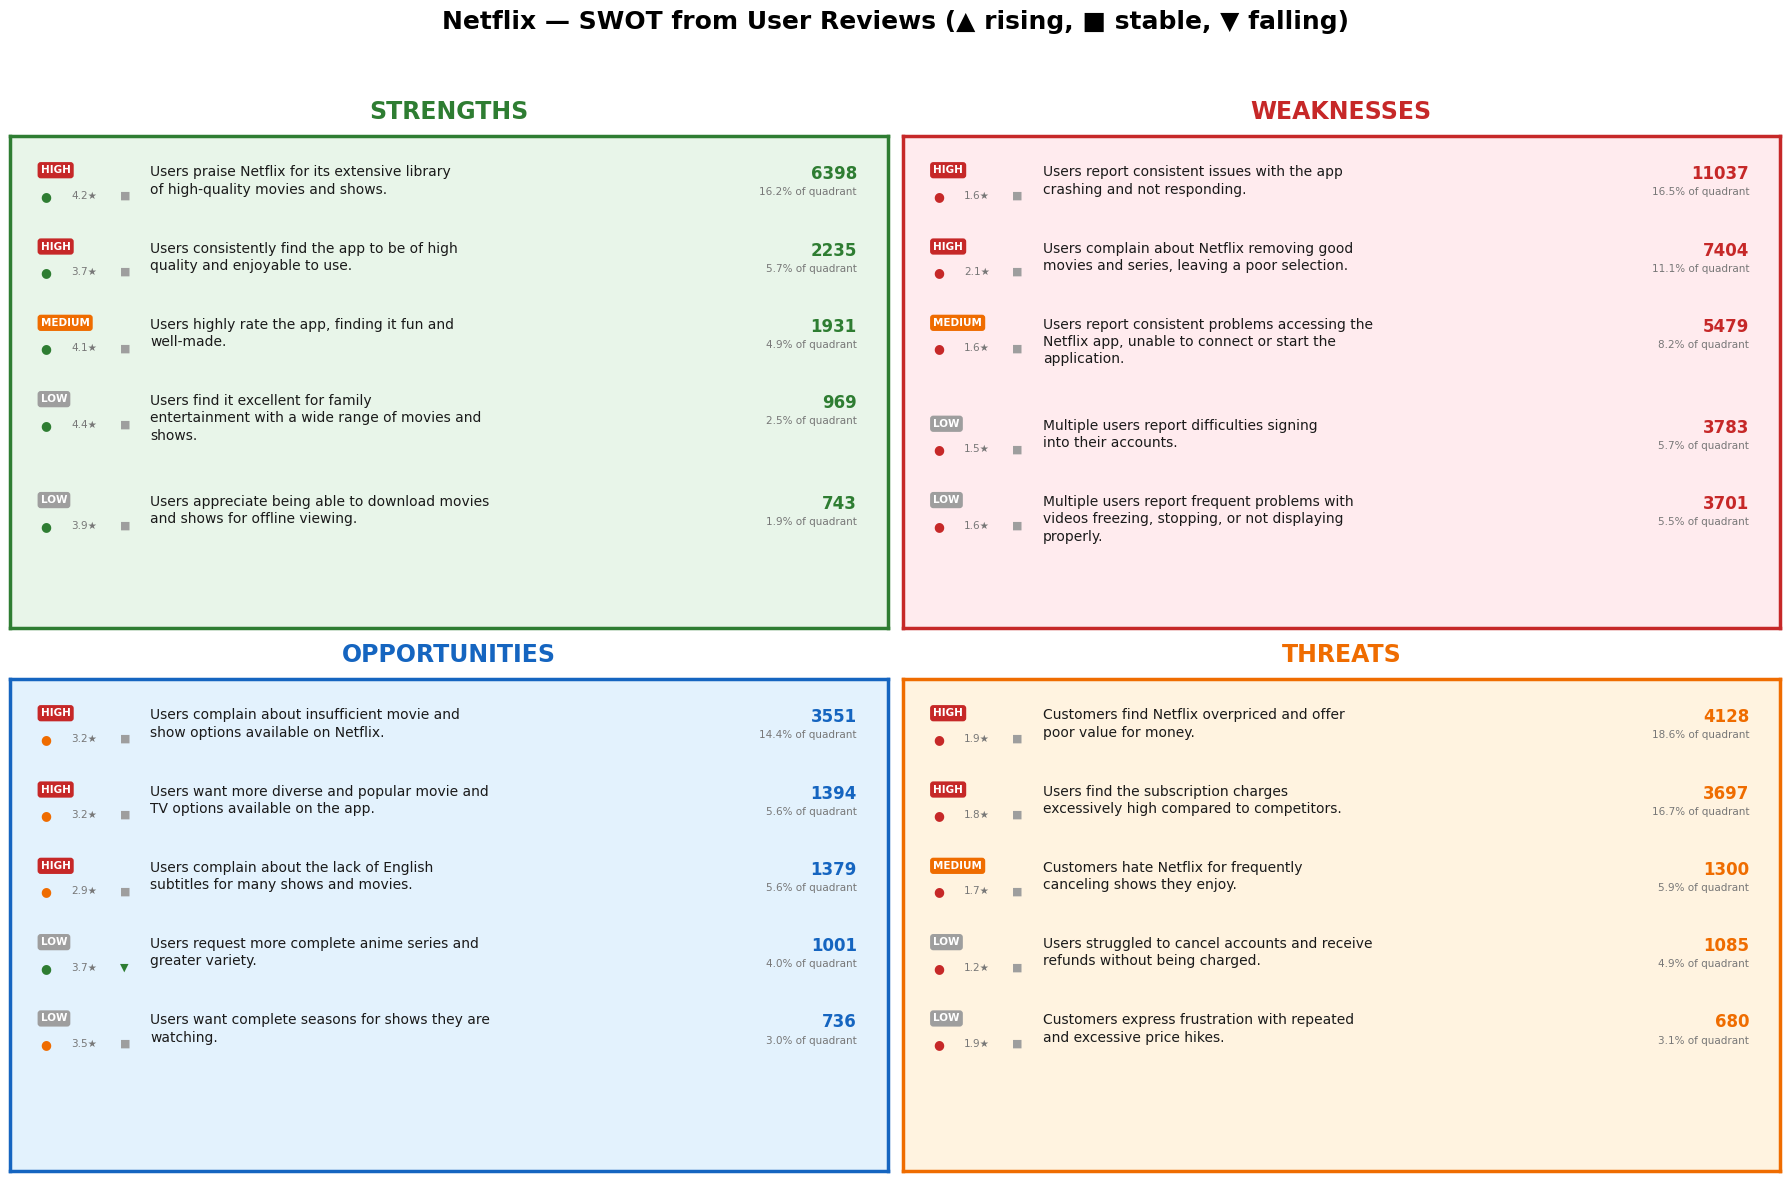

In [39]:
import matplotlib.pyplot as plt
import textwrap

QUAD = {
    "Strength":    ("STRENGTHS",     "#E8F5E9", "#2E7D32", (0, 0)),
    "Weakness":    ("WEAKNESSES",    "#FFEBEE", "#C62828", (0, 1)),
    "Opportunity": ("OPPORTUNITIES", "#E3F2FD", "#1565C0", (1, 0)),
    "Threat":      ("THREATS",       "#FFF3E0", "#EF6C00", (1, 1)),
}
PRIO_COLOR = {"HIGH": "#C62828", "MEDIUM": "#EF6C00", "LOW": "#9E9E9E"}
TREND_MARK = {"RISING": ("\u25b2", "#C62828"), "STABLE": ("\u25a0", "#9E9E9E"),
              "FALLING": ("\u25bc", "#2E7D32")}


def _wrap(t, w=46):
    return "\n".join(textwrap.wrap(str(t), width=w))


def draw_cell(ax, category):
    title, bg, border, _ = QUAD[category]
    sub = (final_swot[final_swot["swot"] == category]
           .sort_values("mention_count", ascending=False).head(5))
    ax.set_facecolor(bg); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    for sp in ax.spines.values():
        sp.set_linewidth(2.5); sp.set_edgecolor(border)
    ax.set_title(title, fontsize=17, fontweight="bold", color=border, pad=12)

    y, line_h, gap = 0.94, 0.05, 0.055
    for _, r in sub.iterrows():
        ax.text(0.035, y, r["priority"], transform=ax.transAxes, fontsize=7.5,
                fontweight="bold", va="top", ha="left", color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc=PRIO_COLOR[r["priority"]], ec="none"))
        ax.text(0.965, y, f'{int(r["mention_count"])}', transform=ax.transAxes,
                fontsize=12, fontweight="bold", va="top", ha="right", color=border)
        ax.text(0.965, y - 0.045, f'{r["share"]:.1f}% of quadrant', transform=ax.transAxes,
                fontsize=7.5, va="top", ha="right", color="#777777")
        wrapped = _wrap(r["business_insight"]); nlines = wrapped.count("\n") + 1
        ax.text(0.16, y, wrapped, transform=ax.transAxes, fontsize=10,
                va="top", ha="left", color="#1a1a1a", linespacing=1.3)
        sent = ("#2E7D32" if r["avg_rating"] >= 3.5
                else "#EF6C00" if r["avg_rating"] >= 2.5 else "#C62828")
        ax.text(0.035, y - 0.05, "\u25cf", transform=ax.transAxes, fontsize=9,
                va="top", ha="left", color=sent)
        ax.text(0.07, y - 0.052, f'{r["avg_rating"]:.1f}\u2605', transform=ax.transAxes,
                fontsize=7.5, va="top", ha="left", color="#777777")
        mark, mcol = TREND_MARK[r["trend"]]
        ax.text(0.125, y - 0.052, mark, transform=ax.transAxes,
                fontsize=8, va="top", ha="left", color=mcol)
        y -= max(nlines, 2) * line_h + gap


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Netflix — SWOT from User Reviews "
             "(\u25b2 rising, \u25a0 stable, \u25bc falling)",
             fontsize=18, fontweight="bold", y=0.98)
for category in QUAD:
    rr, cc = QUAD[category][3]
    draw_cell(axes[rr, cc], category)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/kaggle/working/swot_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
final_swot.to_csv("/kaggle/working/final_swot_matrix.csv", index=False)
print("Saved: final_swot_matrix.csv and swot_matrix.png")

Saved: final_swot_matrix.csv and swot_matrix.png


## 23. Trying it on new reviews

In [41]:
if torch.cuda.is_available():
    classifier_model.to("cuda")
gc.collect(); torch.cuda.empty_cache()


def classify_sentence(sentence):
    segments = split_review_into_segments(sentence) or [sentence]
    p = predict_proba(segments)
    all_labels = set()
    for row in p:
        labels = [SWOT_LABELS[i] for i in range(4) if row[i] >= thr_vec[i]]
        if not labels:
            labels = [SWOT_LABELS[int(np.argmax(row))] + " (low confidence)"]
        all_labels.update(labels)
    return sorted(all_labels), segments


demo = [
    "great app, lots of movies",
    "the app crashes every time i open it",
    "please add greek subtitles",
    "too expensive, i am cancelling and switching to disney",
    "good interface but it keeps freezing",
    "love it but i wish it had more anime",
    "amazing library, great quality, but the price is too high",
]

for sentence in demo:
    labels, segments = classify_sentence(sentence)
    print(f">>> {sentence}")
    print(f"    SWOT: {', '.join(labels)}")
    for seg in segments:
        print(f'      - segment: "{seg}"')
    print()

>>> great app, lots of movies
    SWOT: Strength
      - segment: "great app, lots of movies"

>>> the app crashes every time i open it
    SWOT: Weakness
      - segment: "the app crashes every time i open it"

>>> please add greek subtitles
    SWOT: Opportunity
      - segment: "please add greek subtitles"

>>> too expensive, i am cancelling and switching to disney
    SWOT: Threat
      - segment: "too expensive, i am cancelling and switching to disney"

>>> good interface but it keeps freezing
    SWOT: Weakness
      - segment: "good interface but it keeps freezing"

>>> love it but i wish it had more anime
    SWOT: Opportunity
      - segment: "love it but i wish it had more anime"

>>> amazing library, great quality, but the price is too high
    SWOT: Strength, Threat
      - segment: "amazing library, great quality"
      - segment: "the price is too high"



## 24. Charts and findings

### 24.1 How many segments per category

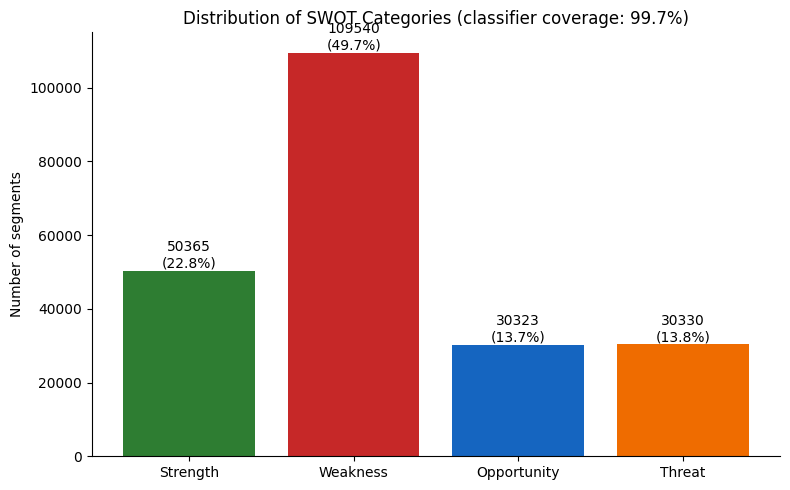

In [42]:
import matplotlib.pyplot as plt

COLORS = {"Strength": "#2E7D32", "Weakness": "#C62828",
          "Opportunity": "#1565C0", "Threat": "#EF6C00"}

counts = CLASSIFIED["swot_category"].value_counts().reindex(SWOT_LABELS).fillna(0)
pct = 100 * counts / counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(SWOT_LABELS, counts.values, color=[COLORS[l] for l in SWOT_LABELS])
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{int(b.get_height())}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of segments")
cov = (df_swot["swot_category"] != UNCLASSIFIED).mean()
ax.set_title(f"Distribution of SWOT Categories (classifier coverage: {cov:.1%})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_swot_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 24.2 Categories by star rating

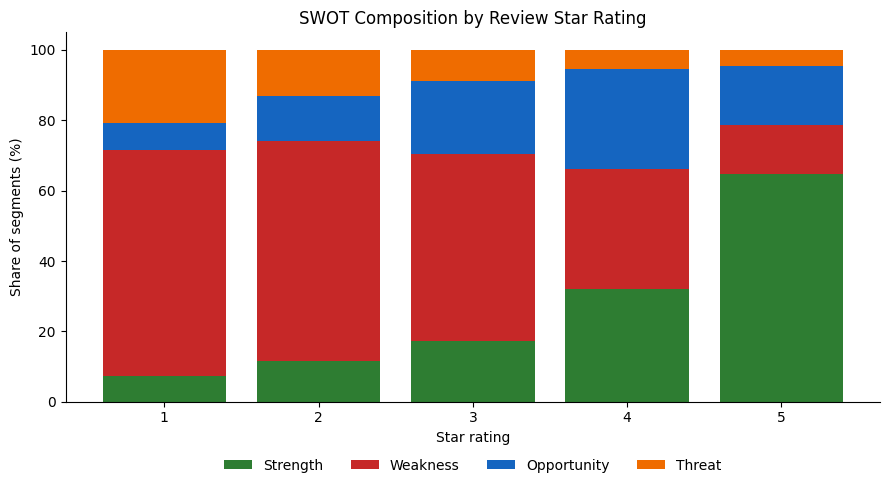

In [43]:
ct = pd.crosstab(CLASSIFIED["rating"], CLASSIFIED["swot_category"]).reindex(
    columns=SWOT_LABELS).fillna(0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(ct_pct))
for lab in SWOT_LABELS:
    ax.bar(ct_pct.index.astype(int).astype(str), ct_pct[lab], bottom=bottom,
           label=lab, color=COLORS[lab])
    bottom += ct_pct[lab].values
ax.set_xlabel("Star rating")
ax.set_ylabel("Share of segments (%)")
ax.set_title("SWOT Composition by Review Star Rating")
ax.legend(ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.12), loc="upper center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_swot_by_rating.png", dpi=150, bbox_inches="tight")
plt.show()

### 24.3 Categories over time

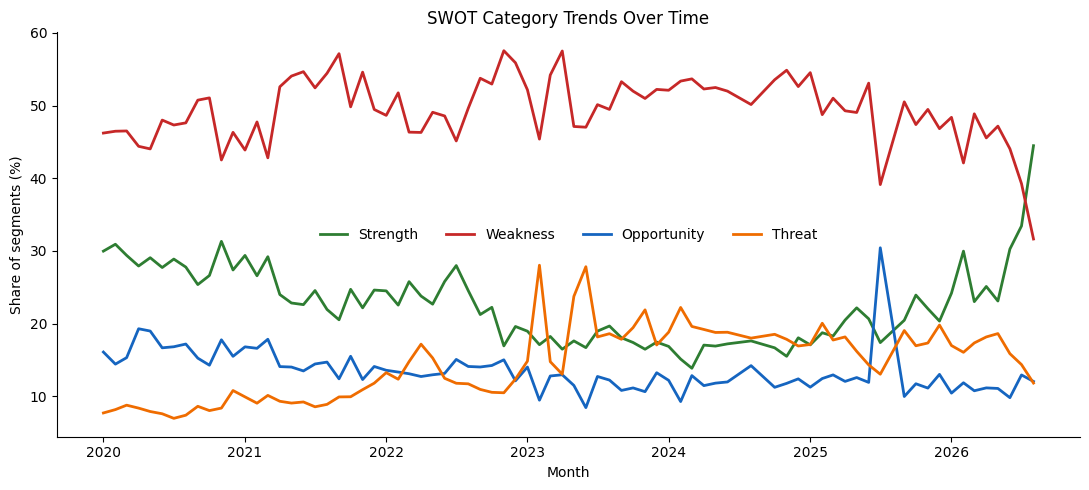

In [44]:
tmp = CLASSIFIED.copy()
tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
tmp = tmp.dropna(subset=["date"])
tmp["month"] = tmp["date"].dt.to_period("M").dt.to_timestamp()
monthly = pd.crosstab(tmp["month"], tmp["swot_category"]).reindex(columns=SWOT_LABELS).fillna(0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
monthly_pct = monthly_pct[monthly.sum(axis=1) >= 20]

fig, ax = plt.subplots(figsize=(11, 5))
for lab in SWOT_LABELS:
    ax.plot(monthly_pct.index, monthly_pct[lab], label=lab, color=COLORS[lab], linewidth=2)
ax.set_xlabel("Month")
ax.set_ylabel("Share of segments (%)")
ax.set_title("SWOT Category Trends Over Time")
ax.legend(ncol=4, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_swot_trend.png", dpi=150, bbox_inches="tight")
plt.show()

### 24.4 The Covid period

Segments in Covid period: 70,129 (31.8% of classified)
Average rating  -  Covid: 2.89 |  Other: 2.24


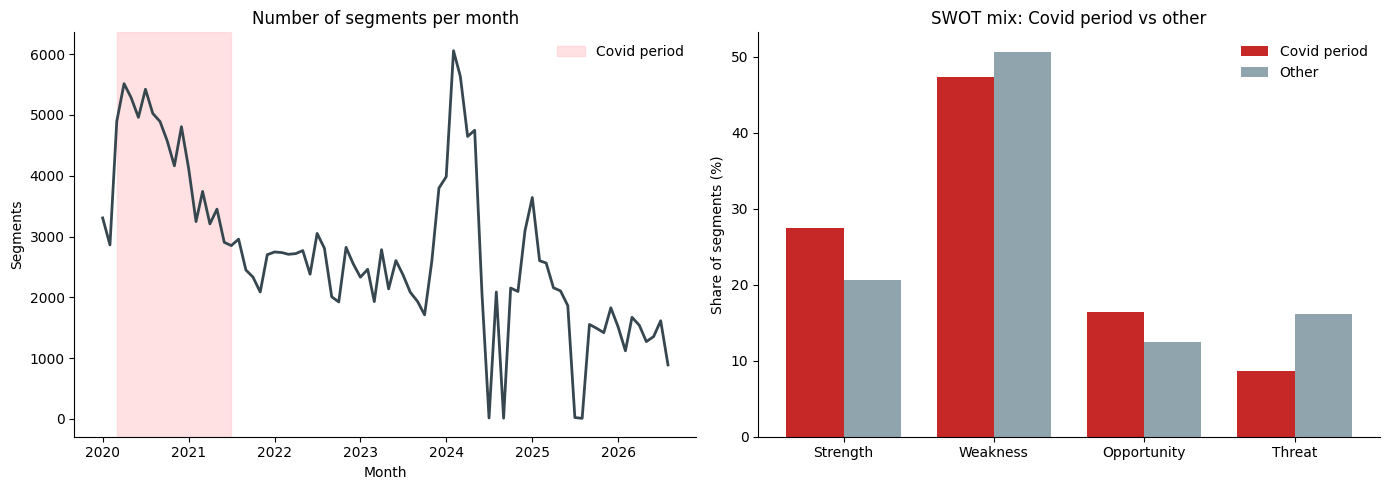


SWOT mix (%):
swot_category  Strength  Weakness  Opportunity  Threat
period                                                
Covid period       27.5      47.4         16.4     8.6
Other              20.7      50.7         12.5    16.1


In [45]:
COVID_START, COVID_END = "2020-03-01", "2021-06-30"

covid_df = CLASSIFIED.copy()
covid_df["date"] = pd.to_datetime(covid_df["date"], errors="coerce")
covid_df = covid_df.dropna(subset=["date"])
covid_df["period"] = np.where(
    (covid_df["date"] >= COVID_START) & (covid_df["date"] <= COVID_END),
    "Covid period", "Other")

print(f"Segments in Covid period: {(covid_df['period'] == 'Covid period').sum():,} "
      f"({(covid_df['period'] == 'Covid period').mean() * 100:.1f}% of classified)")
print(f"Average rating  -  Covid: {covid_df.loc[covid_df['period'] == 'Covid period', 'rating'].mean():.2f} "
      f"|  Other: {covid_df.loc[covid_df['period'] == 'Other', 'rating'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

covid_df["month"] = covid_df["date"].dt.to_period("M").dt.to_timestamp()
vol = covid_df.groupby("month").size()
axes[0].plot(vol.index, vol.values, color="#37474F", linewidth=2)
axes[0].axvspan(pd.to_datetime(COVID_START), pd.to_datetime(COVID_END),
                color="#FFCDD2", alpha=0.6, label="Covid period")
axes[0].set_title("Number of segments per month")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Segments")
axes[0].legend(frameon=False); axes[0].spines[["top", "right"]].set_visible(False)

comp = pd.crosstab(covid_df["period"], covid_df["swot_category"]).reindex(columns=SWOT_LABELS).fillna(0)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100
x = np.arange(len(SWOT_LABELS)); w = 0.38
axes[1].bar(x - w / 2, comp_pct.loc["Covid period"], w, label="Covid period", color="#C62828")
axes[1].bar(x + w / 2, comp_pct.loc["Other"], w, label="Other", color="#90A4AE")
axes[1].set_xticks(x); axes[1].set_xticklabels(SWOT_LABELS)
axes[1].set_ylabel("Share of segments (%)")
axes[1].set_title("SWOT mix: Covid period vs other")
axes[1].legend(frameon=False); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/kaggle/working/fig_covid_period.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSWOT mix (%):")
print(comp_pct.round(1))

### 24.5 Leading themes per category

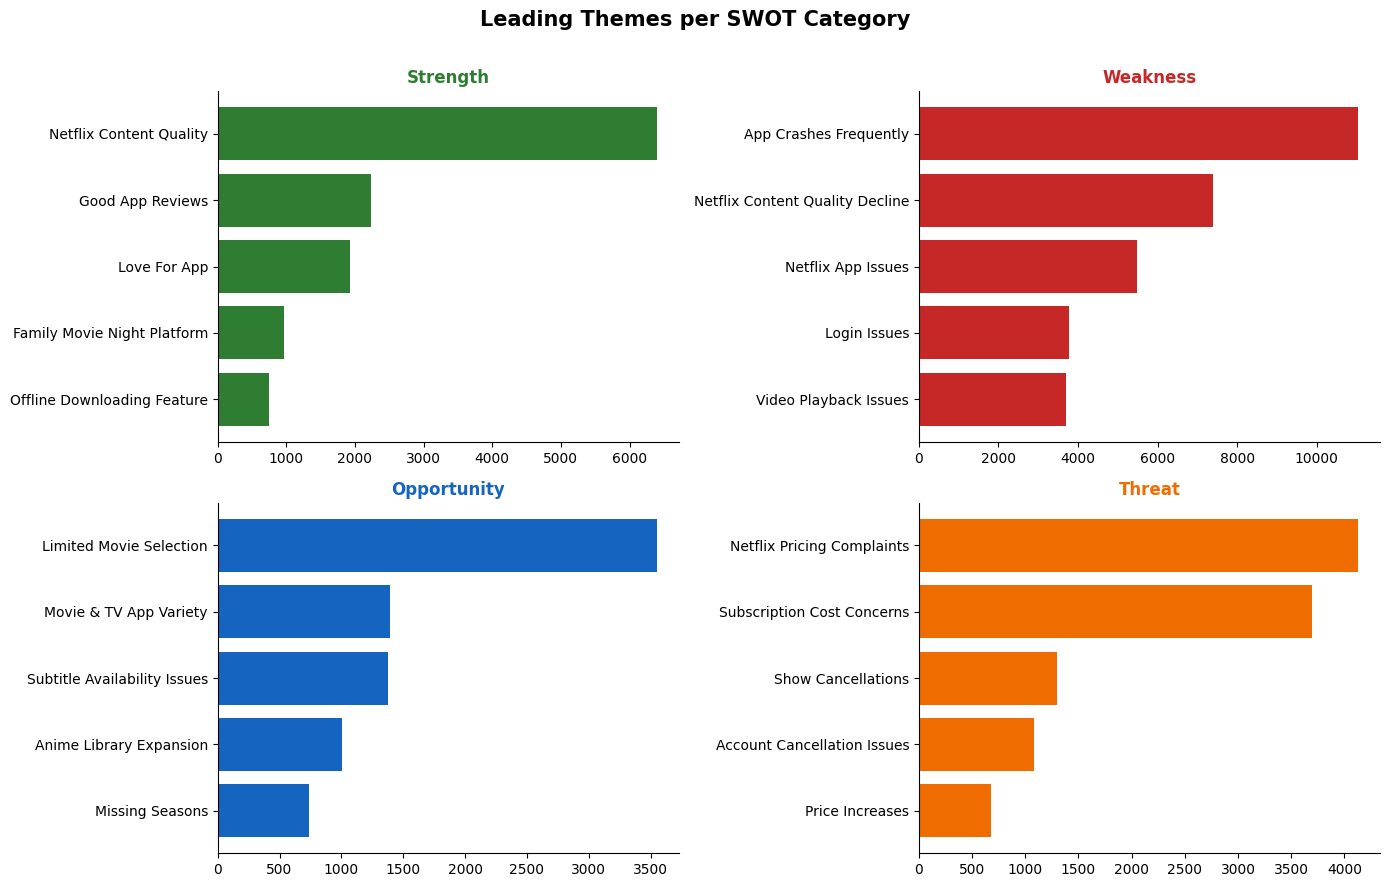

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, cat in zip(axes.ravel(), SWOT_LABELS):
    table = topic_tables.get(cat, pd.DataFrame())
    if len(table) == 0:
        ax.text(0.5, 0.5, f"{cat}\n(no topics)", ha="center", va="center")
        ax.axis("off"); continue
    top = table.head(5)
    phrases = [str(p)[:40] for p in top["topic_name"]][::-1]
    vals = list(top["mention_count"])[::-1]
    ax.barh(phrases, vals, color=COLORS[cat])
    ax.set_title(cat, color=COLORS[cat], fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Leading Themes per SWOT Category", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/kaggle/working/fig_top_topics.png", dpi=150, bbox_inches="tight")
plt.show()

### 24.6 Model performance

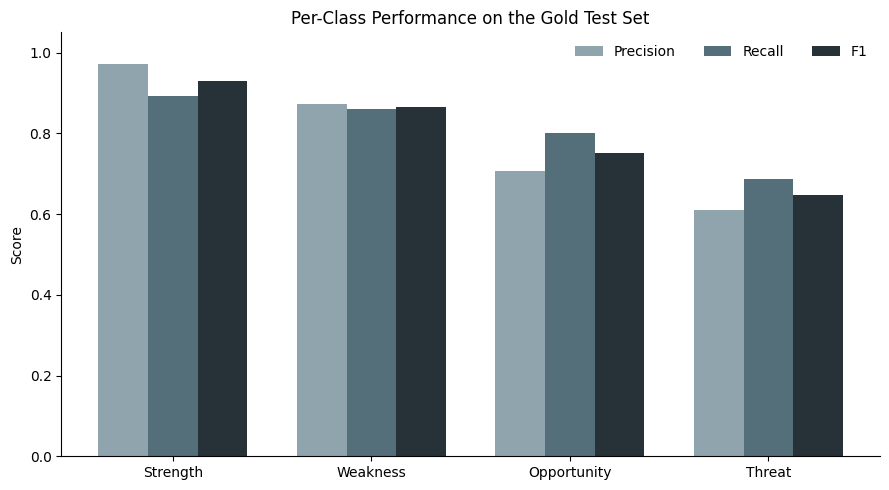

In [47]:
yt_perf = np.array([[1 if t == l else 0 for l in SWOT_LABELS] for t in true_label])
yp_perf = np.array([[1 if p == l else 0 for l in SWOT_LABELS] for p in pred_label])
prec_p, rec_p, f1_p, _ = precision_recall_fscore_support(
    yt_perf, yp_perf, labels=list(range(len(SWOT_LABELS))), zero_division=0)

x = np.arange(len(SWOT_LABELS)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w, prec_p, w, label="Precision", color="#90A4AE")
ax.bar(x, rec_p, w, label="Recall", color="#546E7A")
ax.bar(x + w, f1_p, w, label="F1", color="#263238")
ax.set_xticks(x); ax.set_xticklabels(SWOT_LABELS)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Per-Class Performance on the Gold Test Set")
ax.legend(frameon=False, ncol=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_per_class_perf.png", dpi=150, bbox_inches="tight")
plt.show()

## 25. Which words drive the predictions

Word level occlusion: remove one word at a time and see how much the probability
of the predicted class drops. I use this for the visualizations below. The
formal faithfulness test in Section 23.6 scores the Integrated Gradients
attributions instead.

In [48]:
STOP = {"i", "it", "is", "a", "the", "to", "my", "on", "of", "and", "for", "this",
        "that", "in", "so", "im", "its", "was", "be", "you", "me", "with", "at",
        "as", "are", "have", "but", "or"}


def explain_occlusion(text):
    words = str(text).split()
    if len(words) < 2:
        return None
    base = predict_proba([text])[0]
    cls = int(np.argmax(base)); base_p = float(base[cls])
    variants = [" ".join(words[:i] + words[i + 1:]) for i in range(len(words))]
    p_var = predict_proba(variants)
    contribs = [(words[i], base_p - float(p_var[i][cls])) for i in range(len(words))]
    return {"label": SWOT_LABELS[cls], "confidence": base_p, "contributions": contribs}


def _meaningful(contribs):
    out = []
    for w, v in contribs:
        wl = w.lower().strip(".,!?\"'")
        if wl not in STOP and len(wl) > 2 and abs(v) > 0.01:
            out.append((w, v))
    return out


def plot_attribution(text, ax=None):
    res = explain_occlusion(text)
    if res is None:
        return
    kept = _meaningful(res["contributions"]) or res["contributions"]
    words = [w for w, _ in kept]
    vals = np.array([v for _, v in kept])
    cols = ["#C62828" if v < 0 else COLORS.get(res["label"], "#2E7D32") for v in vals]
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 2.6))
    ax.barh(range(len(words)), vals, color=cols)
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_title(f'Predicted: {res["label"]} ({res["confidence"]:.2f}) — "{text[:45]}…"',
                 fontsize=10)
    ax.set_xlabel("Influence on prediction")
    ax.spines[["top", "right"]].set_visible(False)

### 25.1 A few examples

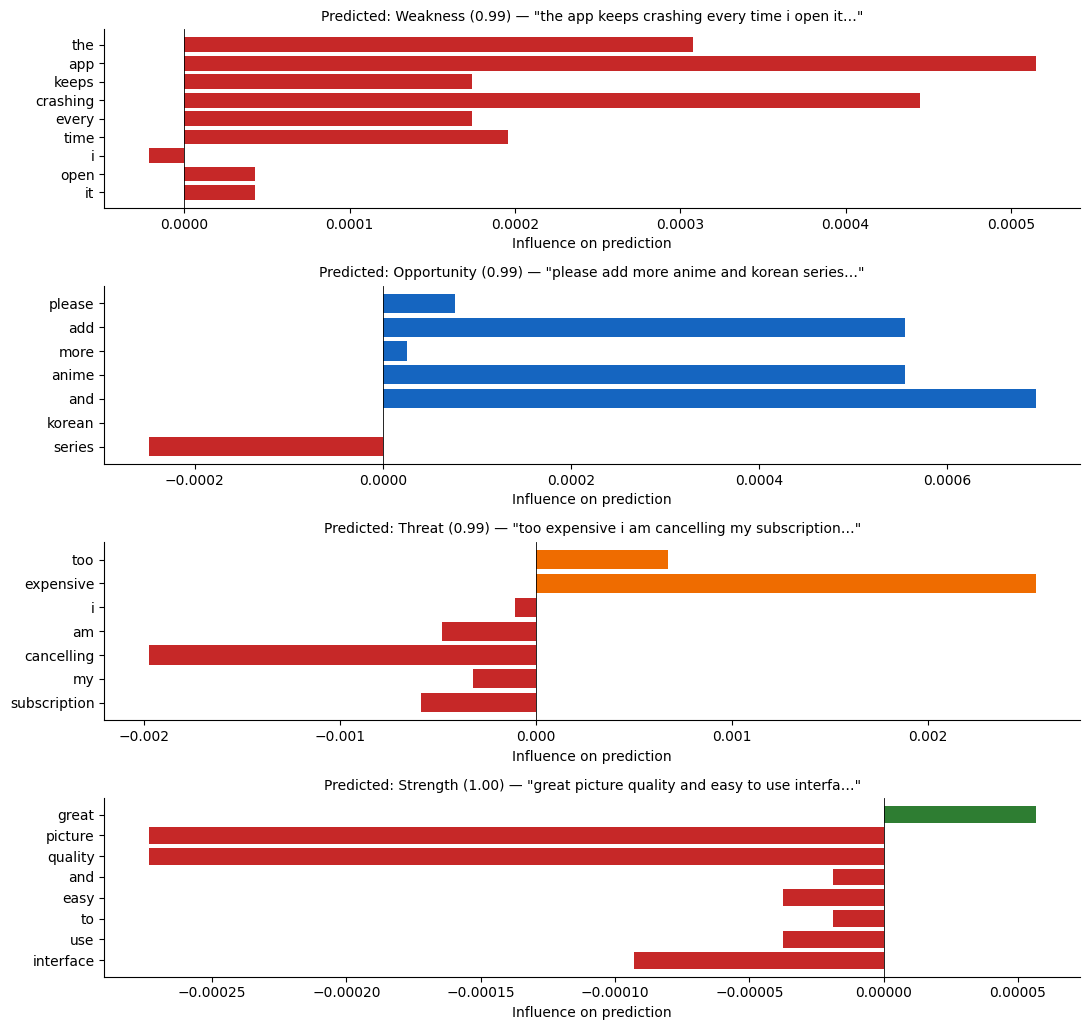

In [49]:
xai_examples = [
    "the app keeps crashing every time i open it",
    "please add more anime and korean series",
    "too expensive i am cancelling my subscription",
    "great picture quality and easy to use interface",
]
fig, axes = plt.subplots(len(xai_examples), 1, figsize=(11, 2.6 * len(xai_examples)))
for ax, ex in zip(axes, xai_examples):
    plot_attribution(ex, ax=ax)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_token_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
from IPython.display import HTML, display


def explain_sentence_html(text):
    res = explain_occlusion(text)
    if res is None:
        return ""
    vals = np.array([v for _, v in res["contributions"]])
    m = float(np.abs(vals).max()) or 1.0
    spans = []
    for w, v in res["contributions"]:
        inten = min(abs(v) / m, 1.0)
        rgb = "46,125,50" if v >= 0 else "198,40,40"
        spans.append(f'<span style="background:rgba({rgb},{inten:.2f});'
                     f'padding:2px 4px;border-radius:3px;margin:1px;">{w}</span>')
    return (f'<div style="font-family:sans-serif;font-size:15px;margin:10px 0;line-height:2.0;">'
            f'<b style="color:{COLORS[res["label"]]};">&rarr; {res["label"]}</b> '
            f'<span style="color:#999;">(confidence {res["confidence"]:.2f})</span><br>'
            + " ".join(spans) + "</div>")


html_examples = [
    "the app keeps crashing every time i open it",
    "great picture quality and very easy to use",
    "please add more korean and anime series",
    "way too expensive now, i am cancelling my subscription",
    "the new update removed my favourite shows",
]
display(HTML("<h4>How the model reads each sentence "
             "(green = pushed toward the label, red = against)</h4>"
             + "".join(explain_sentence_html(t) for t in html_examples)))

### 25.2 A closer look at the mistakes

In [51]:
errors_view = pd.DataFrame({"text": human_test["text_clean"],
                            "true": true_label, "pred": pred_label})
errors_view = errors_view[errors_view["true"] != errors_view["pred"]].head(6)
display(HTML("<h4>Why the model made these mistakes</h4>" +
    "".join(f'<div style="color:#888;font-size:13px;">true: <b>{r.true}</b></div>'
            + explain_sentence_html(r.text) for r in errors_view.itertuples())))

### 25.3 Distinctive vocabulary per category

The words are weighted with TF-IDF, each category counting as one document
against the other three, so the vocabulary that all four share is pushed down
and every cloud shows what is specific to its category.

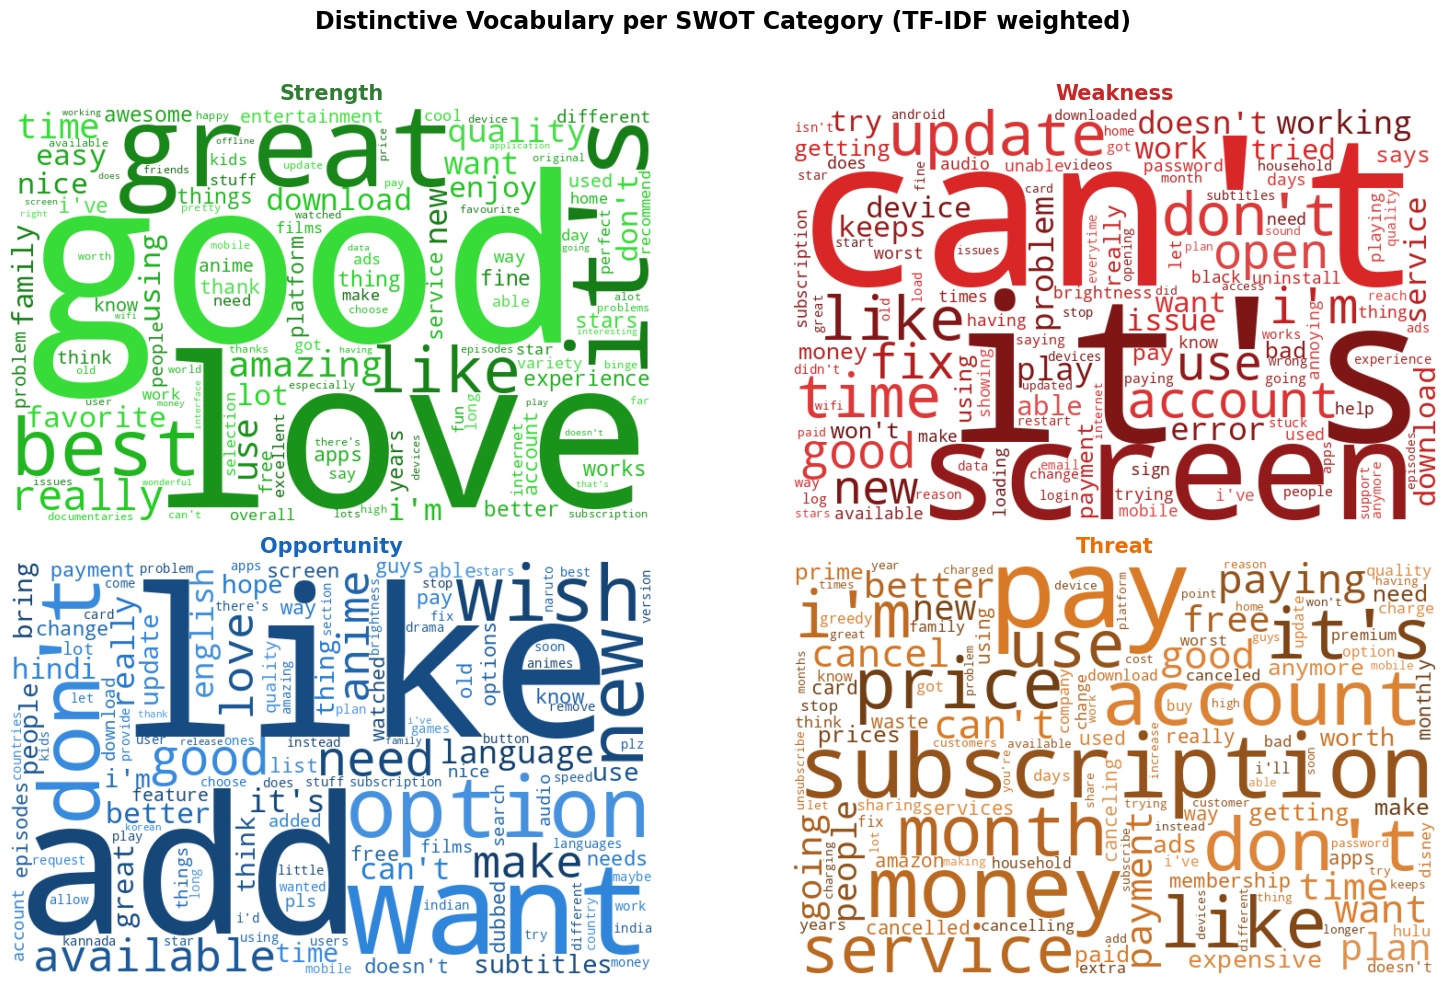

In [52]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

DOMAIN_STOPWORDS = {
    "netflix", "app", "show", "shows", "movie", "movies", "watch", "watching",
    "series", "phone", "tv", "episode", "season", "seasons", "video", "stream",
    "streaming", "content",
}
STOP_LIST = sorted(ENGLISH_STOP_WORDS | DOMAIN_STOPWORDS)

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import random

WC_STOP = STOP_LIST + ["im", "dont", "get", "just", "even", "will", "cant"]
MAX_TEXTS = 20000        # cap per category, otherwise the vectorizer is slow

mega_docs = []
for cat in SWOT_LABELS:
    texts_c = CLASSIFIED.loc[CLASSIFIED["swot_category"] == cat, "text_clean"].astype(str)
    if len(texts_c) > MAX_TEXTS:
        texts_c = texts_c.sample(MAX_TEXTS, random_state=SEED)
    mega_docs.append(" ".join(texts_c))

wc_vec = TfidfVectorizer(stop_words=WC_STOP, max_features=4000,
                         token_pattern=r"[a-zA-Z']{3,}")
X = wc_vec.fit_transform(mega_docs)
vocab = np.array(wc_vec.get_feature_names_out())

BASE_HUE = {"Strength": 120, "Weakness": 0, "Opportunity": 210, "Threat": 28}


def make_color_func(cat):
    def cf(word, font_size, position, orientation, random_state=None, **kw):
        light = 25 + int(random.Random(hash(word)).random() * 35)
        return f"hsl({BASE_HUE[cat]}, 70%, {light}%)"
    return cf


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, (ax, cat) in enumerate(zip(axes.ravel(), SWOT_LABELS)):
    weights = dict(zip(vocab, X[i].toarray().ravel()))
    weights = {w: v for w, v in weights.items() if v > 0}
    ax.axis("off")
    ax.set_title(cat, color=COLORS[cat], fontweight="bold", fontsize=15)
    if weights:
        wc = WordCloud(width=700, height=450, background_color="white",
                       max_words=120, prefer_horizontal=0.9, relative_scaling=0.4,
                       color_func=make_color_func(cat)).generate_from_frequencies(weights)
        ax.imshow(wc, interpolation="bilinear")
fig.suptitle("Distinctive Vocabulary per SWOT Category (TF-IDF weighted)",
             fontsize=17, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("/kaggle/working/fig_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

### 25.4 SHAP

In [53]:
!pip install shap -q

import shap


def shap_predict(texts):
    return predict_proba(list(texts))


masker = shap.maskers.Text(r"\W+")          # mask whole words, not subwords
explainer = shap.Explainer(shap_predict, masker, output_names=SWOT_LABELS)

shap_examples = [
    "the app keeps crashing every time i open it",
    "great picture quality and very easy to use",
    "please add more korean and anime series",
    "way too expensive now i am cancelling my subscription",
    "the new update removed my favourite shows",
]
shap_values = explainer(shap_examples)

for i, txt in enumerate(shap_examples):
    cls = int(np.argmax(predict_proba([txt])[0]))
    print(f"\n-> Predicted: {SWOT_LABELS[cls]}")
    shap.plots.text(shap_values[i, :, cls])


-> Predicted: Weakness



-> Predicted: Strength



-> Predicted: Opportunity



-> Predicted: Threat



-> Predicted: Weakness


### 25.5 LIME on one real review per class

Auto-selected real reviews:
  [Strength] great app , its worldwide used not yet an obsession for me
  [Weakness] your tv app is ridiculous, its been months and its constantly glitches
  [Opportunity] it's good but more ppl should be able to watch shows on different devices
  [Threat] the monthly price keeps going up and the same stuff is on netflix


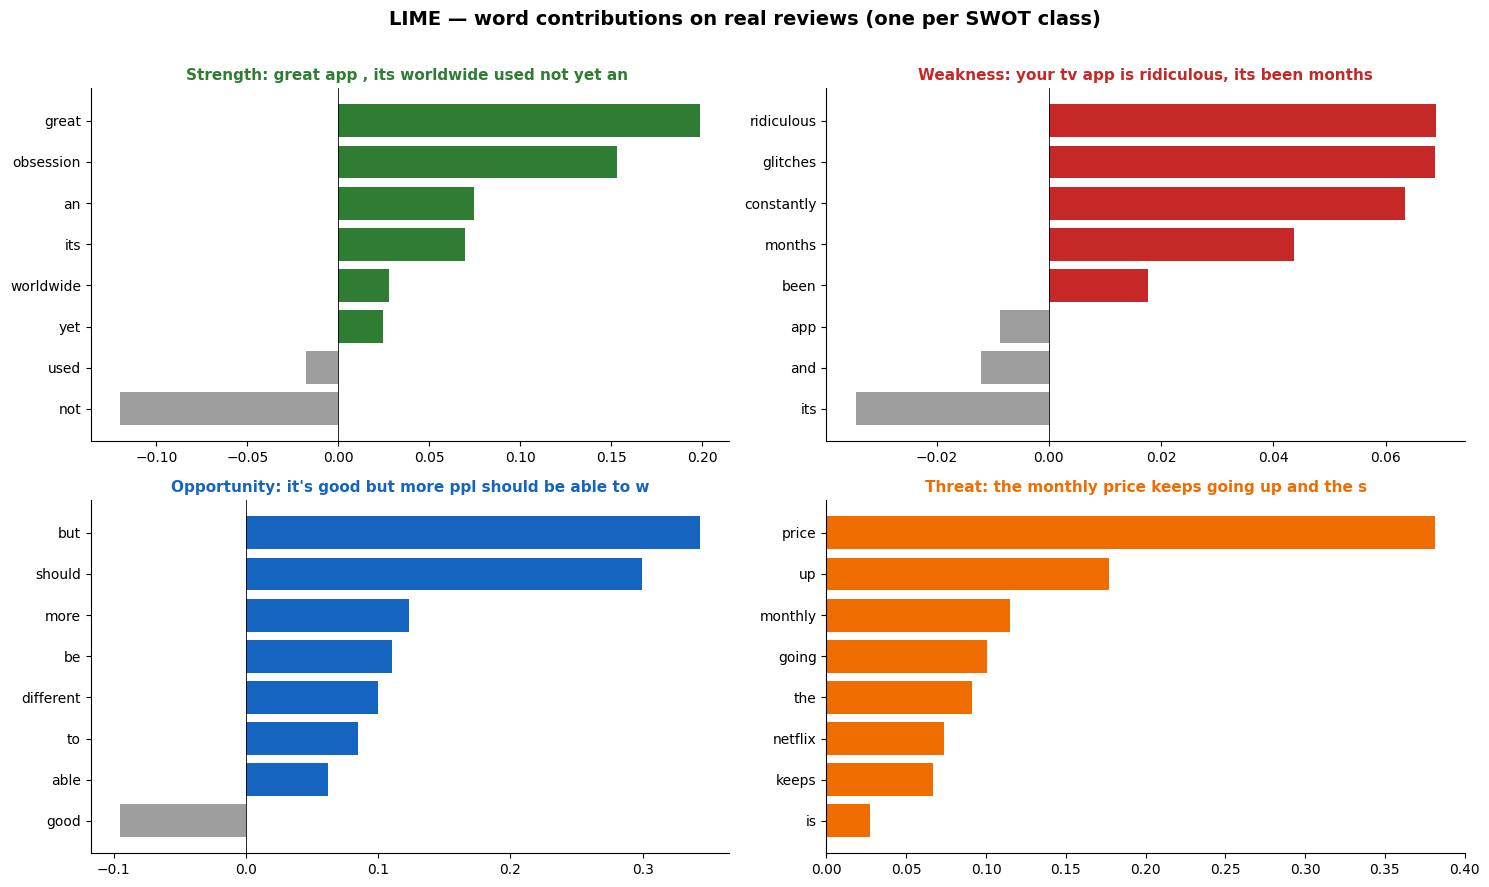

In [54]:
!pip install lime -q
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(class_names=SWOT_LABELS)


def lime_predict(texts):
    return predict_proba(list(texts))


def pick_real_example(cat, min_w=5, max_w=14):
    sub = CLASSIFIED[CLASSIFIED["swot_category"] == cat].copy()
    sub["_nw"] = sub["text_clean"].astype(str).str.split().str.len()
    pool = sub[(sub["_nw"] >= min_w) & (sub["_nw"] <= max_w)]
    if len(pool) == 0:
        pool = sub
    return pool.sort_values("swot_confidence", ascending=False).iloc[0]["text_clean"]


real_examples = [pick_real_example(cat) for cat in SWOT_LABELS]
print("Auto-selected real reviews:")
for cat, ex in zip(SWOT_LABELS, real_examples):
    print(f"  [{cat}] {ex}")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, txt in zip(axes.ravel(), real_examples):
    cls = int(np.argmax(predict_proba([txt])[0]))
    exp = lime_explainer.explain_instance(txt, lime_predict, num_features=8,
                                          labels=[cls], num_samples=800)
    items = sorted(exp.as_list(label=cls), key=lambda x: x[1])
    words = [w for w, _ in items]; vals = [v for _, v in items]
    cols = [COLORS[SWOT_LABELS[cls]] if v >= 0 else "#9E9E9E" for v in vals]
    ax.barh(range(len(words)), vals, color=cols)
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words, fontsize=10)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_title(f"{SWOT_LABELS[cls]}: {txt[:42]}",
                 color=COLORS[SWOT_LABELS[cls]], fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("LIME — word contributions on real reviews (one per SWOT class)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/kaggle/working/fig_lime.png", dpi=150, bbox_inches="tight")
plt.show()

### 25.6 Integrated Gradients and faithfulness

The IG scores are added up from subword tokens to whole words with the character
offsets, so the plots and the deletion/insertion curves use the same word units.
The curves compare the IG order with an occlusion order and with a random
order.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.8 MB/s eta 0:00:00


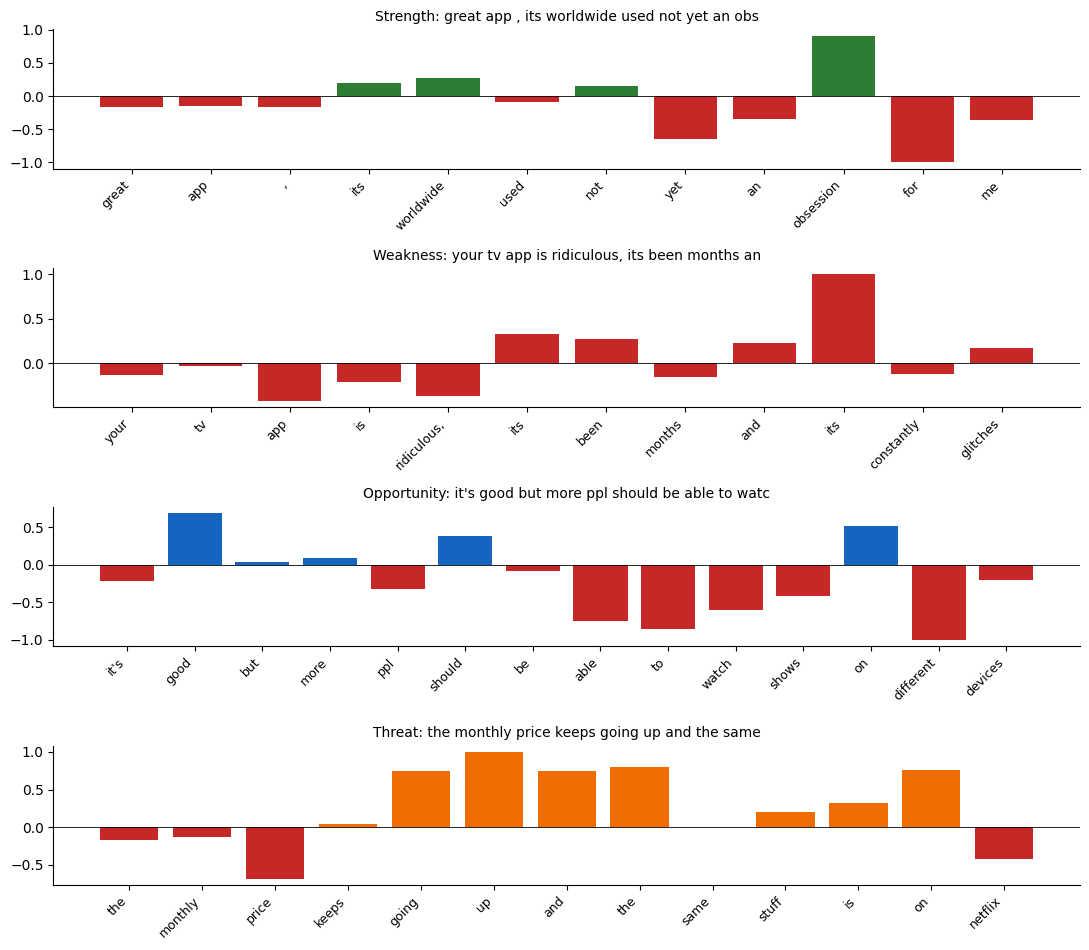

In [55]:
!pip install captum -q
from captum.attr import LayerIntegratedGradients

clf = classifier_model
tok = classifier_tokenizer
device = clf.device


def _forward(input_ids, attention_mask):
    return clf(input_ids=input_ids, attention_mask=attention_mask).logits


lig = LayerIntegratedGradients(_forward, clf.get_input_embeddings())


def ig_word_importance(text):
    """IG scores per token, added up per whole word using the char offsets."""
    text = str(text)
    words = text.split()
    if len(words) < 2:
        return None, None, None
    spans, pos = [], 0
    for w in words:
        start = text.find(w, pos)
        spans.append((start, start + len(w)))
        pos = start + len(w)
    enc = tok(text, return_tensors="pt", truncation=True, max_length=64,
              return_offsets_mapping=True)
    offsets = enc.pop("offset_mapping")[0].tolist()
    enc = {k: v.to(device) for k, v in enc.items()}
    ids, mask = enc["input_ids"], enc["attention_mask"]
    with torch.no_grad():
        cls = int(clf(input_ids=ids, attention_mask=mask).logits.argmax())
    ref = torch.full_like(ids, tok.pad_token_id)
    ref[0, 0] = ids[0, 0]; ref[0, -1] = ids[0, -1]
    attr = lig.attribute(inputs=ids, baselines=ref, additional_forward_args=(mask,),
                         target=cls, n_steps=40)
    tok_scores = attr.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    imp = np.zeros(len(words))
    for (s, e), sc in zip(offsets, tok_scores):
        if e == 0:                      # skip [CLS], [SEP] etc
            continue
        for wi, (ws, we) in enumerate(spans):
            if ws <= s < we:
                imp[wi] += sc
                break
    return words, cls, imp


fig, axes = plt.subplots(len(real_examples), 1, figsize=(11, 2.4 * len(real_examples)))
for ax, txt in zip(axes, real_examples):
    words, cls, imp = ig_word_importance(txt)
    if imp is None:
        continue
    vals = imp / (np.abs(imp).max() + 1e-9)
    cols = ["#C62828" if v < 0 else COLORS[SWOT_LABELS[cls]] for v in vals]
    ax.bar(range(len(words)), vals, color=cols)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right", fontsize=9)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(f"{SWOT_LABELS[cls]}: {txt[:45]}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_integrated_gradients.png", dpi=150, bbox_inches="tight")
plt.show()

AOPC (higher = more faithful ordering):
  IG         deletion = 0.430 | insertion = 0.445
  Occlusion  deletion = 0.507 | insertion = 0.543
  Random     deletion = 0.321 | insertion = 0.366

IG gain over random: deletion +0.108 | insertion +0.079


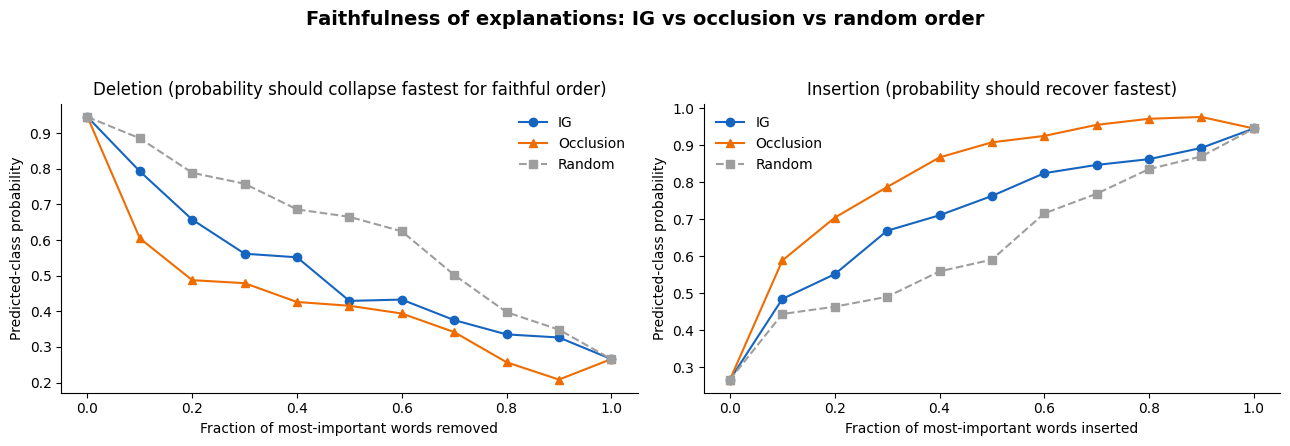

In [56]:
# deletion / insertion curves for three word orders: IG, occlusion and random
STEPS = 10
FR = np.linspace(0, 1, STEPS + 1)
rng_f = np.random.RandomState(SEED)


def occlusion_word_importance(text):
    words = str(text).split()
    if len(words) < 2:
        return None, None, None
    base = predict_proba([text])[0]
    cls = int(np.argmax(base)); base_p = float(base[cls])
    variants = [" ".join(words[:i] + words[i + 1:]) for i in range(len(words))]
    p_var = predict_proba(variants)
    imp = np.array([base_p - float(p_var[i][cls]) for i in range(len(words))])
    return words, cls, imp


def curves_for_order(words, cls, order):
    n = len(words)
    del_txts = [" ".join([w for j, w in enumerate(words)
                          if j not in set(order[:int(round(f * n))])]) for f in FR]
    ins_txts = [" ".join([w for j, w in enumerate(words)
                          if j in set(order[:int(round(f * n))])]) for f in FR]
    dp = predict_proba([t if t.strip() else " " for t in del_txts])[:, cls]
    ip = predict_proba([t if t.strip() else " " for t in ins_txts])[:, cls]
    return dp, ip


#sample of real reviews
faith_sample = CLASSIFIED.copy()
faith_sample["_nw"] = faith_sample["text_clean"].astype(str).str.split().str.len()
faith_sample = faith_sample[(faith_sample["_nw"] >= 5) & (faith_sample["_nw"] <= 20)]
faith_sample = faith_sample.groupby("swot_category").head(15)      # about 60 reviews

curves = {"IG": {"del": [], "ins": []},
          "Occlusion": {"del": [], "ins": []},
          "Random": {"del": [], "ins": []}}

for t in faith_sample["text_clean"]:
    words, cls, imp_ig = ig_word_importance(t)
    if imp_ig is None:
        continue
    _, _, imp_oc = occlusion_word_importance(t)
    orders = {"IG": np.argsort(-imp_ig),
              "Occlusion": np.argsort(-imp_oc),
              "Random": rng_f.permutation(len(words))}
    for name, order in orders.items():
        dp, ip = curves_for_order(words, cls, order)
        curves[name]["del"].append(dp)
        curves[name]["ins"].append(ip)

aopc = {}
for name, cs in curves.items():
    D = np.array(cs["del"]); I = np.array(cs["ins"])
    aopc[name] = {"del": float(np.mean(D[:, 0:1] - D)),
                  "ins": float(np.mean(I - I[:, 0:1])),
                  "D": D, "I": I}

print("AOPC (higher = more faithful ordering):")
for name in ["IG", "Occlusion", "Random"]:
    print(f"  {name:10} deletion = {aopc[name]['del']:.3f} | insertion = {aopc[name]['ins']:.3f}")
print(f"\nIG gain over random: deletion {aopc['IG']['del'] - aopc['Random']['del']:+.3f} "
      f"| insertion {aopc['IG']['ins'] - aopc['Random']['ins']:+.3f}")

STYLE = {"IG": ("#1565C0", "o", "-"), "Occlusion": ("#EF6C00", "^", "-"),
         "Random": ("#9E9E9E", "s", "--")}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in ["IG", "Occlusion", "Random"]:
    col, mk, ls = STYLE[name]
    axes[0].plot(FR, aopc[name]["D"].mean(0), marker=mk, color=col,
                 linestyle=ls, label=name)
    axes[1].plot(FR, aopc[name]["I"].mean(0), marker=mk, color=col,
                 linestyle=ls, label=name)
axes[0].set_title("Deletion (probability should collapse fastest for faithful order)")
axes[0].set_xlabel("Fraction of most-important words removed")
axes[0].set_ylabel("Predicted-class probability")
axes[1].set_title("Insertion (probability should recover fastest)")
axes[1].set_xlabel("Fraction of most-important words inserted")
axes[1].set_ylabel("Predicted-class probability")
for ax in axes:
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Faithfulness of explanations: IG vs occlusion vs random order",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/kaggle/working/fig_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()

## 26. Exporting the data for the dashboard (`data.json`)

Last step of the run. Writes the results into `/kaggle/working/data.json`, in the
format the dashboard reads when it loads.

In [57]:
# builds data.json in the format the dashboard expects


def _py(o):
    """numpy/pandas scalars -> plain python, otherwise json.dump complains."""
    if isinstance(o, dict):          return {k: _py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_py(v) for v in o]
    if isinstance(o, np.integer):    return int(o)
    if isinstance(o, np.floating):   return float(o)
    if isinstance(o, np.bool_):      return bool(o)
    return o


# lookup: quote text -> (rating, "Mon YYYY")
_cl = CLASSIFIED.copy()
_cl["date"] = pd.to_datetime(_cl["date"], errors="coerce")
_cl["text_clean"] = _cl["text_clean"].astype(str)
_quote_lookup = {}
for _t, _r, _d in zip(_cl["text_clean"], _cl["rating"], _cl["date"]):
    _t = _t.strip()
    if _t and _t not in _quote_lookup:
        _quote_lookup[_t] = (int(_r) if pd.notna(_r) else 3,
                             _d.strftime("%b %Y") if pd.notna(_d) else "")


def _quote_meta(text, fallback_rating):
    text = str(text).strip()
    hit = _quote_lookup.get(text)
    if hit:
        return [hit[0], text, hit[1]]
    return [int(round(fallback_rating)), text, ""]


# topics: the final_swot rows, with the quotes taken back from topic_tables
_topics, _counters = [], {c: 0 for c in SWOT_LABELS}
_prefix = {"Strength": "s", "Weakness": "w", "Opportunity": "o", "Threat": "t"}
for _, row in final_swot.iterrows():
    cat = row["swot"]
    tbl = topic_tables.get(cat, pd.DataFrame())
    match = tbl[tbl["topic_name"] == row["topic_name"]] if len(tbl) else tbl
    if len(match):
        raw_quotes = [match.iloc[0].get(f"quote_{i}", "") for i in range(1, 7)]
    else:
        raw_quotes = [row.get("quote_1", "")]
    avg_r = float(row["avg_rating"])
    quotes = [_quote_meta(q, avg_r) for q in raw_quotes if str(q).strip()]
    _counters[cat] += 1
    _topics.append({
        "id": f"{_prefix[cat]}{_counters[cat]}",
        "quad": cat,
        "name": str(row["topic_name"]),
        "phrase": str(row["topic_phrase"]),
        "mentions": int(row["mention_count"]),
        "avgRating": round(avg_r, 1),
        "trend": str(row["trend"]),
        "prio": str(row["priority"]),
        "insight": str(row["business_insight"]),
        "quotes": quotes,
    })

# meta
_meta = {
    "total_reviews":      int(df_swot["review_id"].nunique()),
    "total_opinions":     int(len(df_swot)),
    "avg_rating":         round(float(df_raw["rating"].mean()), 2),
    "positive_share_pct": round(float((df_raw["rating"] >= 4).mean()) * 100, 1),
    "coverage_pct":       round(float(globals().get("coverage",
                              (df_swot["swot_category"] != UNCLASSIFIED).mean())) * 100, 1),
    "macro_f1":           round(float(globals().get("macro_f1", 0.0)), 2),
}

# history: last 6 finished months, cumulative, for the small KPI charts
_rr = df_raw.dropna(subset=["date"]).copy()
_rr["date"] = pd.to_datetime(_rr["date"], errors="coerce")
_rr = _rr.dropna(subset=["date"]).sort_values("date")
_rr["month"] = _rr["date"].dt.to_period("M")
_this_month = pd.Timestamp.today().to_period("M")
_months = [m for m in sorted(_rr["month"].unique()) if m < _this_month]
_history = []
for _m in (_months[-6:] if len(_months) >= 6 else _months):
    _upto = _rr[_rr["month"] <= _m]
    _history.append({
        "total_reviews":      int(len(_upto)),
        "avg_rating":         round(float(_upto["rating"].mean()), 2),
        "positive_share_pct": round(float((_upto["rating"] >= 4).mean()) * 100, 1),
    })

# totals per quadrant
_quadTotals = {c: int(QUAD_TOTALS.get(c, 0)) for c in SWOT_LABELS}

# heatmap: share of each category inside every star rating
_ct = pd.crosstab(CLASSIFIED["rating"], CLASSIFIED["swot_category"]) \
        .reindex(index=[1, 2, 3, 4, 5], columns=SWOT_LABELS).fillna(0)
_ct_pct = _ct.div(_ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
_heatmap = {c: [int(round(_ct_pct.loc[r, c])) for r in [1, 2, 3, 4, 5]] for c in SWOT_LABELS}

# how many reviews per star
_rc = df_raw["rating"].value_counts().reindex([1, 2, 3, 4, 5]).fillna(0)
_ratingCounts = [int(_rc.loc[r]) for r in [1, 2, 3, 4, 5]]

# quarterly shares per category, from 2021Q1 on
_cq = CLASSIFIED.copy()
_cq["date"] = pd.to_datetime(_cq["date"], errors="coerce")
_cq = _cq.dropna(subset=["date"])
_cq["q"] = _cq["date"].dt.to_period("Q")
_qidx = [q for q in sorted(_cq["q"].unique()) if q >= pd.Period("2021Q1")]
_tct = pd.crosstab(_cq["q"], _cq["swot_category"]) \
         .reindex(index=_qidx, columns=SWOT_LABELS).fillna(0)
_tct_pct = _tct.div(_tct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
_trend = {c: [round(float(_tct_pct.loc[q, c]), 1) for q in _qidx] for c in SWOT_LABELS}

# segments per quarter in thousands, plus the covid window
_vidx = [q for q in sorted(_cq["q"].unique()) if q >= pd.Period("2020Q1")]
_vc = _cq["q"].value_counts().reindex(_vidx).fillna(0)
_volume_counts = [round(float(_vc.loc[q]) / 1000, 1) for q in _vidx]
_lo = _vidx.index(pd.Period("2020Q2")) if pd.Period("2020Q2") in _vidx else 1
_hi = _vidx.index(pd.Period("2021Q2")) if pd.Period("2021Q2") in _vidx else 5

_max_d = pd.to_datetime(df_raw["date"], errors="coerce").max()
_period_label = "Jan 2020 \u2013 " + (_max_d.strftime("%b %Y") if pd.notna(_max_d) else "now")

data_json = _py({
    "generated_at": pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC"),
    "period_label": _period_label,
    "meta":         _meta,
    "history":      _history,
    "quadTotals":   _quadTotals,
    "topics":       _topics,
    "heatmap":      _heatmap,
    "ratingCounts": _ratingCounts,
    "trend":        _trend,
    "volume":       {"counts": _volume_counts, "covid_range": [_lo, _hi]},
})

_OUT = "/kaggle/working/data.json"
with open(_OUT, "w", encoding="utf-8") as _f:
    json.dump(data_json, _f, ensure_ascii=False, indent=2)

print("Wrote", _OUT)
print(json.dumps(data_json["meta"], indent=2))
print(f"topics: {len(data_json['topics'])} | "
      f"trend quarters: {len(_trend['Strength'])} | "
      f"volume quarters: {len(_volume_counts)}")


Wrote /kaggle/working/data.json
{
  "total_reviews": 102622,
  "total_opinions": 221283,
  "avg_rating": 2.85,
  "positive_share_pct": 42.3,
  "coverage_pct": 99.7,
  "macro_f1": 0.8
}
topics: 20 | trend quarters: 23 | volume quarters: 27


## 27. Summary

The reviews are cleaned, deduplicated and split into short opinions.
Qwen2.5-7B labels a sample of them, a RoBERTa-large classifier is trained on
that sample together with my own annotations, and it is tested on a gold set
split by review, with baselines, a McNemar test and bootstrap intervals, under
both the argmax rule and the production rule. Then the whole corpus is labelled
with the coverage reported, BERTopic finds the topics of each quadrant, the weak
topics are filtered out, and the LLM turns what is left into the final SWOT
matrix with priorities and trend flags.

The main limitations: the gold test set is small (132 segments), the silver
labels come from a model and not from people, and the calibration slice is too
small to say anything strong about ALPHA.